## **Machine Learning for Quantum and Classical Systems.**
### **Assignment 1. Variational Quantum Circuits for ground state properties of the XXZ model.**

Author:  Helena Monsó Mas

Affilation:  Master in Quantum Science and Technology, Universitat de Barcelona

Email:  hmonsoma52@alumnes.ub.edu

*Code adapted from tutorials of the Machine Learning for Quantum and Classical Systems Course, Master in Quantum Science and Technology, Barcelona, 2025-2026.*

*Specifically:*
- *Lecture 4:* `04_VQE.ipynb`
- *Lecture 7:* `00_tutorial_Exact_Diagonalizaion_and_unsupervised_analysis_of_quantum_XXZ_model.ipyn`

*Author: Marcin Płodzień*

### **1. Exact Diagonalisation**

We first import all necessary libraries and define the necessary operators and functions.

In [ ]:
from tqdm import tqdm
import numpy as np
import pandas as pd
from scipy.linalg import eigh, cholesky
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from functools import reduce
import torch
import torch.nn as nn

In [ ]:
# Define Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
identity = np.eye(2, dtype=complex)

Operators Construction: `construct_operator` and `total_spin_operator` build spin operators for the system.

In [ ]:
def construct_sigma_operator(sigma, L, site):
    """
    Constructs an operator acting on a specific site in an L-spin system.

    Args:
        pauli (np.ndarray): Pauli matrix for the operator.
        L (int): Number of spins.
        site (int): Site index (0-based) where the operator acts.

    Returns:
        np.ndarray: Operator acting on the full L-spin system.
    """
    operators = [identity if i != site else sigma for i in range(L)]
    return reduce(np.kron, operators)

def total_sigma_operator(L, sigma):
    """
    Construct the total spin operator for a specific component.

    Args:
        L (int): Number of spins.
        pauli (np.ndarray): Pauli matrix for the spin component (x, y, or z).

    Returns:
        np.ndarray: Total spin operator matrix.
    """
    return sum(construct_sigma_operator(sigma, L, i) for i in range(L))

Hamiltonian Construction: `xxz_hamiltonian` constructs the XXZ model Hamiltonian.

Exact Diagonalization: `exact_ground_state` finds the ground state of the Hamiltonian.

In [ ]:
def xxz_hamiltonian(L, delta):
    """
    Construct the XXZ Hamiltonian for L spins with anisotropy delta.

    Args:
        L (int): Number of spins.
        delta (float): Anisotropy parameter.
    Returns:
        np.ndarray: The XXZ Hamiltonian matrix.
    """
    # Hamiltonian
    H = np.zeros((2**L, 2**L), dtype=complex)
    for i in range(L-1):

        j = i+1

        sigma_x_i = construct_sigma_operator(sigma_x, L, i)
        sigma_x_j = construct_sigma_operator(sigma_x, L, j)

        sigma_y_i = construct_sigma_operator(sigma_y, L, i)
        sigma_y_j = construct_sigma_operator(sigma_y, L, j)

        sigma_z_i = construct_sigma_operator(sigma_z, L, i)
        sigma_z_j = construct_sigma_operator(sigma_z, L, j)

        H += -( np.dot(sigma_x_i, sigma_x_j) + np.dot(sigma_y_i, sigma_y_j) + delta * np.dot(sigma_z_i, sigma_z_j) )

    return H

def exact_ground_state(H):
    """
    Compute the ground state of a Hamiltonian via exact diagonalization.

    Args:
        H (np.ndarray): Hamiltonian matrix.

    Returns:
        tuple: Ground state wavefunction and its energy.
    """
    # Ground state wavefunction and energy
    eigenvalues, eigenvectors = eigh(H)
    psi_0 = eigenvectors[:, 0]
    return psi_0,  eigenvalues[0:5]

Now, we calculate and store in pandas dataframe all quantities of interest. We will loop over $\delta\in[-2,2]$ for $L=2,3,...,10$, and store the dataframe to file.

In [ ]:
L_values = range(2,11)
delta_values = np.linspace(-2,2,9)

results_energies = []

for L in tqdm(L_values, desc="Processing L"):
    for delta in delta_values:
        H = xxz_hamiltonian(L, delta)
        psi_0, energies = exact_ground_state(H)
        gs_energy = energies[0]
        results_energies.append([L, delta, gs_energy])

# Create DataFrame
df_energies_ED = pd.DataFrame(results_energies, columns=["L", "delta", "E_gs"])

Processing L: 100%|██████████| 9/9 [02:04<00:00, 13.79s/it]


And now we are ready for our first plot: Ground State Energy vs $\delta$ for different values of $L$.

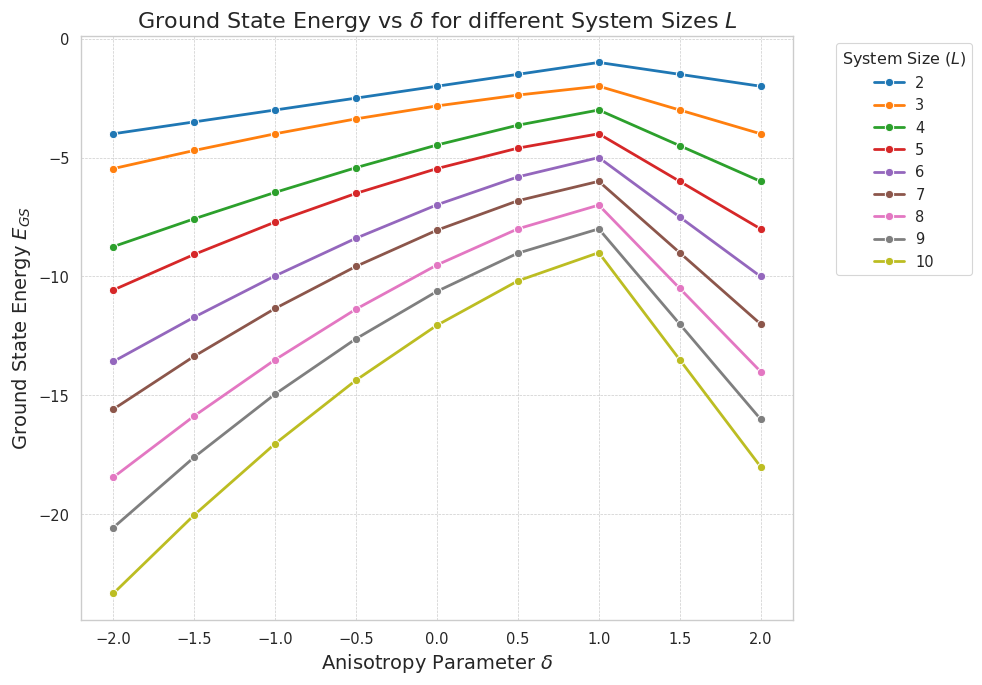

In [ ]:
df_energies_ED["L"] = df_energies_ED["L"].astype(int)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.figure(figsize=(10, 7))

sns.lineplot(
    data=df_energies_ED,
    x="delta",
    y="E_gs",
    hue=df_energies_ED["L"].astype(str),
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2.0
)

plt.xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
plt.ylabel(r"Ground State Energy $E_{GS}$", fontsize=14)
plt.title(r"Ground State Energy vs $\delta$ for different System Sizes $L$", fontsize=16)
plt.grid(True, linestyle="--", linewidth=0.5)

plt.legend(title="System Size ($L$)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

To compute the bipartite entanglement entropy we now define functions to compute partial traces and von Neumann entropy.

In [ ]:
def density_matrix(psi):
    """
    Construct the density matrix for a given state.
    """
    # Density matrix
    return np.outer(psi, psi.conj())

def reduced_density_matrix(L, density_matrix):
    """
    Construct the reduced density matrix by tracing out the first half of the qubits.
    """
    # Reduced density matrix
    L_A = L // 2
    L_B = L - L_A

    rho_reshaped = density_matrix.reshape(2**L_A, 2**L_B, 2**L_A, 2**L_B)

    reduced_rho = np.einsum("a i a j -> i j", rho_reshaped)

    return reduced_rho

def density_matrix_entropy(rho):
    """
    Computes the Von Neumann entropy: S = -Tr(rho * ln(rho))
    """
    # Von Newumann Entropy
    eigenvalues = np.linalg.eigvalsh(rho)
    eigenvalues = eigenvalues[eigenvalues > 0]
    entropy = -np.sum(eigenvalues * np.log(eigenvalues))

    return entropy

def bipartite_entanglement_entropy(L, psi):
    """
    Wrapper to compute entropy from state vector.
    """
    # Bipartite Entropy
    rho = density_matrix(psi)
    rho_B = reduced_density_matrix(L, rho)
    return density_matrix_entropy(rho_B)

In [ ]:
results_entropies = []

for L in tqdm(L_values, desc="Processing L"):
    for delta in delta_values:
        H = xxz_hamiltonian(L, delta)
        psi_0, energies = exact_ground_state(H)
        entropy = bipartite_entanglement_entropy(L, psi_0)
        results_entropies.append([L, delta, entropy])

# Create DataFrame
df_entropies_ED = pd.DataFrame(results_entropies, columns=["L", "delta", "Entropy"])

Processing L: 100%|██████████| 9/9 [02:14<00:00, 14.94s/it]


And now we are ready for our second plot: Entanglement Entropy vs $\delta$ for different values of $L$.

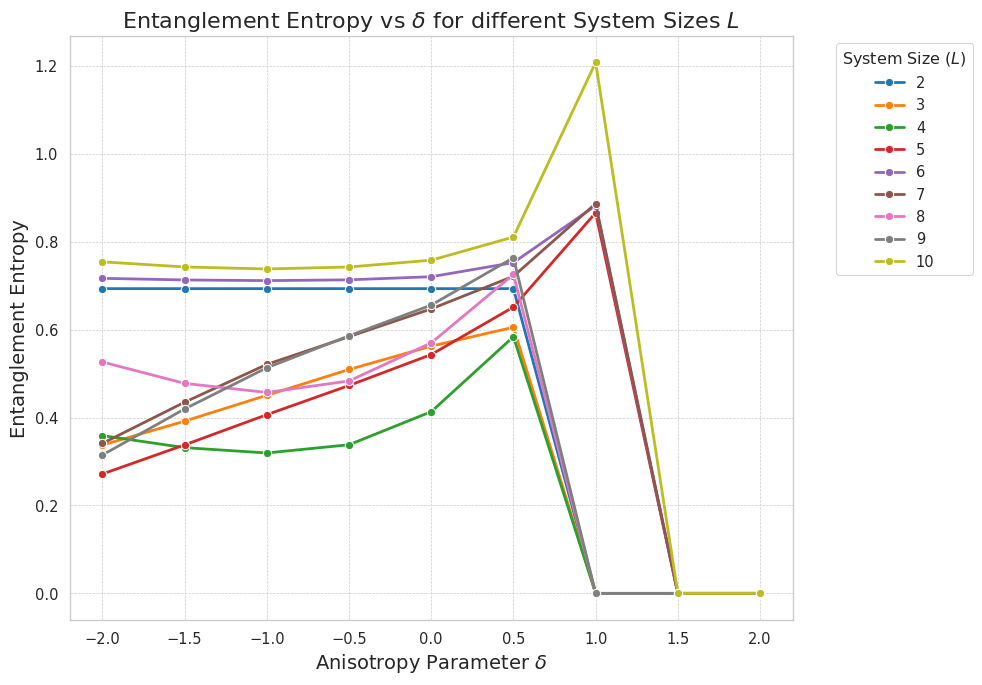

In [ ]:
df_entropies_ED["L"] = df_entropies_ED["L"].astype(int)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.figure(figsize=(10, 7))

sns.lineplot(
    data=df_entropies_ED,
    x="delta",
    y="Entropy",
    hue=df_entropies_ED["L"].astype(str),
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2.0
)

plt.xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
plt.ylabel(r"Entanglement Entropy", fontsize=14)
plt.title(r"Entanglement Entropy vs $\delta$ for different System Sizes $L$", fontsize=16)
plt.grid(True, linestyle="--", linewidth=0.5)

plt.legend(title="System Size ($L$)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Finally, to finish Task 1, we need to ploot the total magnetisation $\langle \hat{\tau}\rangle$ and variance $\langle \Delta^2\hat{\tau}\rangle$, where $\tau=X,Y,Z$.

We define the following function

In [ ]:
def get_expectation_and_variance(psi, Operator):
    """
    Calculate <O> and Variance <O^2> - <O>^2 for a given operator matrix O.
    """
    # Expectation value <psi|O|psi>
    exp_val = np.vdot(psi, Operator @ psi).real

    # Expectation of O^2: <psi|O*O|psi>
    exp_sq = np.vdot(psi, Operator @ (Operator @ psi)).real

    # Variance
    variance = exp_sq - (exp_val ** 2)

    return exp_val, variance

In [ ]:
results_expectations_variances = []

for L in tqdm(L_values, desc="Processing L"):
    for delta in delta_values:

      # Total X, Y and Z
      X_total = total_sigma_operator(L, sigma_x)
      Y_total = total_sigma_operator(L, sigma_y)
      Z_total = total_sigma_operator(L, sigma_z)

      H = xxz_hamiltonian(L, delta)

      psi_0, energies = exact_ground_state(H)

      # Expectations and variances
      exp_x, var_x = get_expectation_and_variance(psi_0, X_total)
      exp_y, var_y = get_expectation_and_variance(psi_0, Y_total)
      exp_z, var_z = get_expectation_and_variance(psi_0, Z_total)

      results_expectations_variances.append([L, delta, exp_x, var_x, exp_y, var_y, exp_z, var_z])

# Create DataFrame
df_expectations_variances_ED = pd.DataFrame(results_expectations_variances, columns=["L", "delta", "exp_x", "var_x", "exp_y", "var_y", "exp_z", "var_z"])

Processing L: 100%|██████████| 9/9 [02:08<00:00, 14.33s/it]


And we are ready to plot.

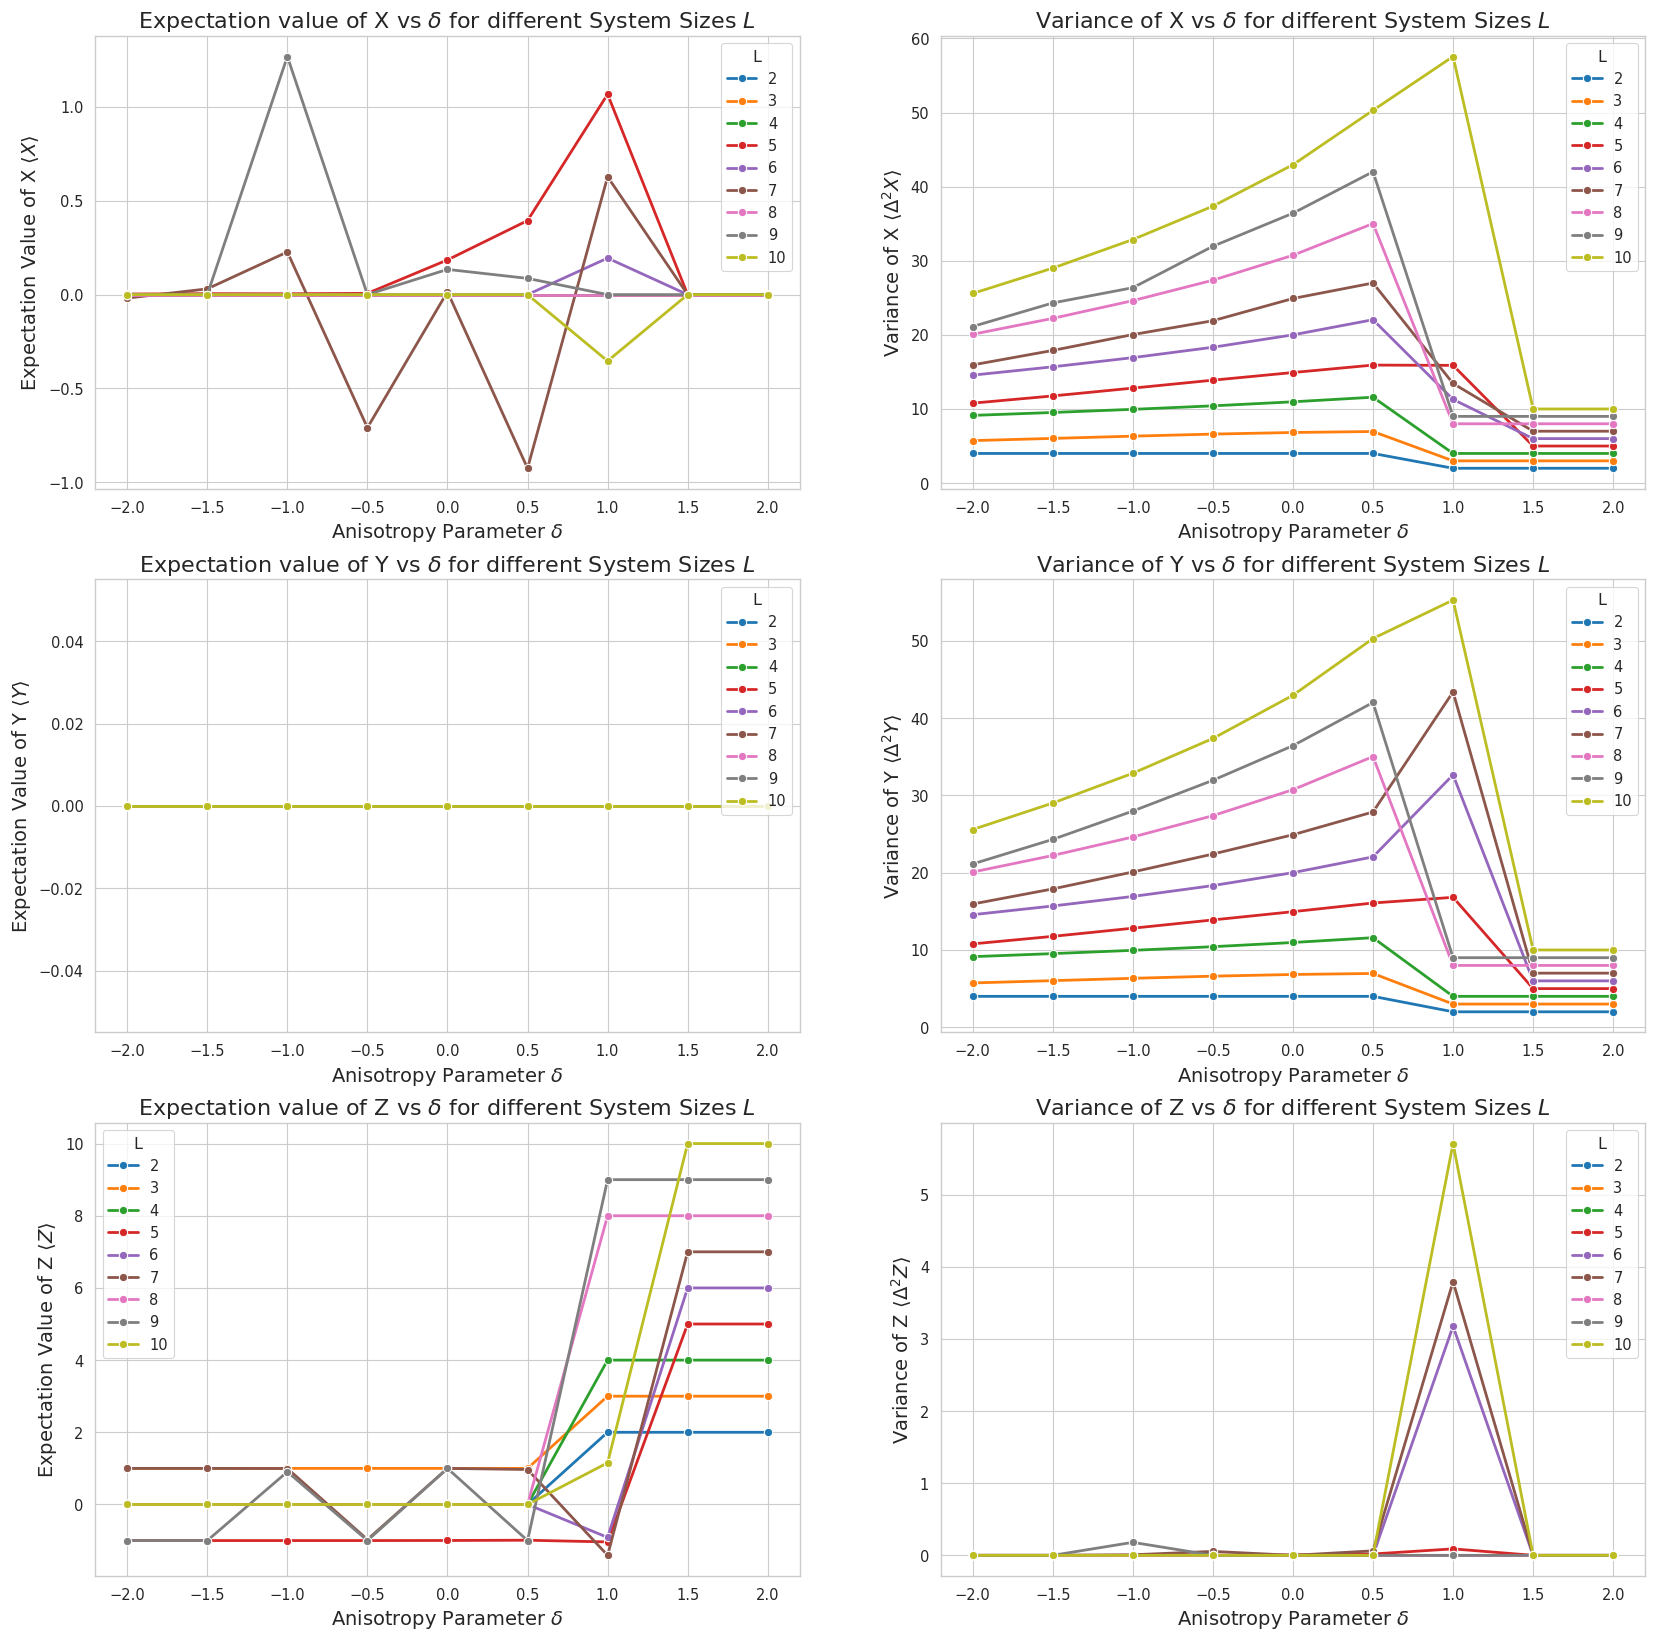

In [ ]:
fig, axes = plt.subplots(3,2,figsize=(20,20))

hue_data = df_expectations_variances_ED["L"].astype(int)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

#Plots for X
sns.lineplot(
    data=df_expectations_variances_ED,
    x="delta",
    y="exp_x",
    hue=hue_data,
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2,
    ax=axes[0, 0]
)
axes[0,0].set_title(r"Expectation value of X vs $\delta$ for different System Sizes $L$", fontsize=16)
axes[0,0].set_xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
axes[0,0].set_ylabel(r"Expectation Value of X $\langle X \rangle$", fontsize=14)
sns.lineplot(
    data=df_expectations_variances_ED,
    x="delta",
    y="var_x",
    hue=hue_data,
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2.0,
    ax=axes[0, 1]
)
axes[0,1].set_title(r"Variance of X vs $\delta$ for different System Sizes $L$", fontsize=16)
axes[0,1].set_xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
axes[0,1].set_ylabel(r"Variance of X $\langle \Delta^2 X \rangle$", fontsize=14)

#Plots for Y
sns.lineplot(
    data=df_expectations_variances_ED,
    x="delta",
    y="exp_y",
    hue=hue_data,
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2.0,
    ax=axes[1, 0]
)
axes[1,0].set_title(r"Expectation value of Y vs $\delta$ for different System Sizes $L$", fontsize=16)
axes[1,0].set_xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
axes[1,0].set_ylabel(r"Expectation Value of Y $\langle Y \rangle$", fontsize=14)
sns.lineplot(
    data=df_expectations_variances_ED,
    x="delta",
    y="var_y",
    hue=hue_data,
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2.0,
    ax=axes[1, 1]
)
axes[1,1].set_title(r"Variance of Y vs $\delta$ for different System Sizes $L$", fontsize=16)
axes[1,1].set_xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
axes[1,1].set_ylabel(r"Variance of Y $\langle \Delta^2 Y \rangle$", fontsize=14)

#Plots for Z
sns.lineplot(
    data=df_expectations_variances_ED,
    x="delta",
    y="exp_z",
    hue=hue_data,
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2.0,
    ax=axes[2, 0]
)
axes[2,0].set_title(r"Expectation value of Z vs $\delta$ for different System Sizes $L$", fontsize=16)
axes[2,0].set_xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
axes[2,0].set_ylabel(r"Expectation Value of Z $\langle Z \rangle$", fontsize=14)
sns.lineplot(
    data=df_expectations_variances_ED,
    x="delta",
    y="var_z",
    hue=hue_data,
    palette="tab10",
    marker="o",
    markersize=6,
    linewidth=2.0,
    ax=axes[2, 1]
)
axes[2,1].set_title(r"Variance of Z vs $\delta$ for different System Sizes $L$", fontsize=16)
axes[2,1].set_xlabel(r"Anisotropy Parameter $\delta$", fontsize=14)
axes[2,1].set_ylabel(r"Variance of Z $\langle \Delta^2 Z \rangle$", fontsize=14);


And with this, Task 1 is finished!

### **2. Variational Quantum Circuits**

We will propose three different ansatz architectures for the XXZ model:

1. Hardware Efficient: Ry/Rz rotations + nearest-neighbor CNOTs
2. Hamiltonian Inspired: Ry/Rz rotations + Nearest-neighbor Rxx/Ryy/Rzz gates.
3. All to All: Ry/Rz rotations + Global Connectivity with Rxx/Ryy/Rzz gates

Firstly, we need to define all gates needed for our variational circuits.

In [ ]:
# Pauli matrices
Pauli_X = torch.tensor([[0, 1], [1, 0]], dtype=torch.complex128)
Pauli_Y = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.complex128)
Pauli_Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128)

# Single Qubit Rotations: R_P(\theta)=e^{i\theta/2}P=cos(\theta/2)I-i sin(\theta/2)P
def rx_matrix(theta):
    """
    Returns Rx(theta) = exp(-i * theta/2 * X)
    Shape: (Batch, 2, 2) or (2, 2)
    """
    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)

    # R_x = [[cos, -i*sin], [-i*sin, cos]]
    row1 = torch.stack([c, -1j * s], dim=-1)
    row2 = torch.stack([-1j * s, c], dim=-1)
    return torch.stack([row1, row2], dim=-2).type(torch.complex128)

def ry_matrix(theta):
    """
    Returns Ry(theta) = exp(-i * theta/2 * Y)
    Shape: (Batch, 2, 2) or (2, 2)
    """
    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)

    # R_y = [[cos, -sin], [sin, cos]]
    row1 = torch.stack([c, -s], dim=-1)
    row2 = torch.stack([s, c], dim=-1)
    return torch.stack([row1, row2], dim=-2).type(torch.complex128)

def rz_matrix(theta):
    """
    Returns Rz(theta) = exp(-i * theta/2 * Z)
    Shape: (Batch, 2, 2) or (2, 2)
    """
    # R_z = [[e^{-i t/2}, 0], [0, e^{i t/2}]]
    phase_m = torch.exp(-1j * theta / 2)
    phase_p = torch.exp(1j * theta / 2)
    zero = torch.zeros_like(theta)

    row1 = torch.stack([phase_m, zero], dim=-1)
    row2 = torch.stack([zero, phase_p], dim=-1)
    return torch.stack([row1, row2], dim=-2).type(torch.complex128)

# CNOT Matrix
CNOT_mat = torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
], dtype=torch.complex128)

# Two-qubit Parameterized Entanglers: R_PP(\theta)=e^{-i\theta/2 P \otimes P}=cos(\theta/2)I-i sin(\theta/2)(P \otimes P)

def rxx_matrix(theta):
    """
    Returns Rxx(theta) = exp(-i * theta/2 * X otimes X)
    Effect: Flips |00> to |11> and |01> to |10> with phase.
    """
    c = torch.cos(theta / 2)
    s = -1j * torch.sin(theta / 2)

    mat = torch.zeros((theta.shape[0], 4, 4), dtype=torch.complex128, device=theta.device)

    mat[:, 0, 0] = c; mat[:, 1, 1] = c
    mat[:, 2, 2] = c; mat[:, 3, 3] = c

    mat[:, 0, 3] = s; mat[:, 3, 0] = s
    mat[:, 1, 2] = s; mat[:, 2, 1] = s

    return mat

def ryy_matrix(theta):
    """
    Returns Ryy(theta) = exp(-i * theta/2 * Y otimes Y)
    """
    c = torch.cos(theta / 2)
    s_val = torch.sin(theta / 2)

    mat = torch.zeros((theta.shape[0], 4, 4), dtype=torch.complex128, device=theta.device)

    mat[:, 0, 0] = c; mat[:, 1, 1] = c
    mat[:, 2, 2] = c; mat[:, 3, 3] = c

    mat[:, 0, 3] = 1j * s_val
    mat[:, 3, 0] = 1j * s_val

    mat[:, 1, 2] = -1j * s_val
    mat[:, 2, 1] = -1j * s_val

    return mat

def rzz_matrix(theta):
    """
    Returns Rzz(theta) = exp(-i * theta/2 * Z otimes Z)
    """

    phase_m = torch.exp(-1j * theta / 2)
    phase_p = torch.exp(1j * theta / 2)

    diag = torch.stack([phase_m, phase_p, phase_p, phase_m], dim=-1)
    return torch.diag_embed(diag).type(torch.complex128)

We now define functions to apply the gates, i.e. to apply the matrices defined above to our quantum state vector

In [ ]:
def apply_one_qubit_gate(state, gate, target_qubit, L):
    """
    Applies a 2x2 gate to a specific qubit.
    state: Tensor of shape (2, 2, ..., 2)
    """
    # Target qubit to the front
    all_indices = list(range(L))
    all_indices.pop(target_qubit)
    perm_target_first = [target_qubit] + all_indices

    state = state.permute(perm_target_first)

    # Reshape to (2, 2^(L-1))
    shape_original = state.shape
    state_2d = state.reshape(2, -1)

    # Apply Gate
    state_2d = gate @ state_2d

    # Restore original shape and order
    state = state_2d.reshape(shape_original)
    inv_perm = np.argsort(perm_target_first).tolist()
    state = state.permute(inv_perm)

    return state

def apply_two_qubit_gate(state, gate, q1, q2, L):
    """
    Applies a 4x4 gate to qubits q1 and q2.
    """
    # Permute q1 and q2 to the front
    all_indices = list(range(L))
    all_indices.remove(q1)
    all_indices.remove(q2)
    perm_target_first = [q1, q2] + all_indices

    state = state.permute(perm_target_first)

    # Reshape to (4, 2^(L-2))
    shape_original = state.shape
    state_2d = state.reshape(4, -1)

    # Apply Gate
    state_2d = gate @ state_2d

    # Restore
    state = state_2d.reshape(shape_original)
    inv_perm = np.argsort(perm_target_first).tolist()
    state = state.permute(inv_perm)

    return state

def get_gate_matrix(gate_func, theta_val):
    """
    Handles the shape requirements for the specific gate definitions provided.
    Some gates (rxx, ryy, rzz) require a batch dimension.
    """
    # Helper to handle scalar vs batch inputs for gate definitions
    if theta_val.ndim == 0:
        t_in = theta_val.view(1)
    else:
        t_in = theta_val

    mat = gate_func(t_in)

    if mat.ndim == 3 and mat.shape[0] == 1:
        mat = mat.squeeze(0)

    return mat

def get_initial_state(L):
    """Returns |00...0> state with shape (2, 2, ..., 2)"""
    # Initialization Helper
    dim = 2**L
    state = torch.zeros(dim, dtype=torch.complex128)
    state[0] = 1.0 + 0j # |00...0>

    return state.reshape([2]*L)

def fetch_params(theta, idx, count):
    """
    Helper to fetch a chunk of parameters from the main theta vector.

    Args:
        theta (Tensor): The full parameter vector.
        idx (int): Current index pointer.
        count (int): How many parameters to fetch.

    Returns:
        (Tensor slice, int): The parameters and the new index pointer.
    """
    if idx + count > len(theta):
        raise ValueError(f"Theta index out of range. Needed {count} params at idx {idx}, but len is {len(theta)}")

    return theta[idx : idx + count], idx + count

And now we define the three ansatzes we mentioned before

In [ ]:
# ANSATZ 1: Hardware Efficient
# Structure: Ry, Rz on all qubits + Nearest Neighbor CNOTs

def ansatz_hardware_efficient(theta, L, depth):
    """
    Ansatz 1: Hardware Efficient
    Structure per layer:
      0. We initialise X on all qubits (creates |111...>)
      The repetition block consists of
      1. A first layer of rotations Ry, Rz on every qubit.
      2. Followed by CNOTs on NEIGHBOURING qubits (i, i+1)
    """
    # Parameter check: 2 params (Ry, Rz) per qubit per layer
    # Note: CNOTs have no parameters, so they don't affect theta count
    params_per_layer = 2 * L
    if len(theta) != params_per_layer * depth:
        raise ValueError(f"Ansatz 1 requires {params_per_layer*depth} params, got {len(theta)}")

    state = get_initial_state(L)
    idx = 0

    # 1. Initialization: Layer of X
    for i in range(L):
        state = apply_one_qubit_gate(state, Pauli_X, i, L)

    # 2. Repeating Layers
    for _ in range(depth):
        # Rotations: Ry then Rz on every qubit
        for i in range(L):
            state = apply_one_qubit_gate(state, get_gate_matrix(ry_matrix, theta[idx]), i, L); idx += 1
            state = apply_one_qubit_gate(state, get_gate_matrix(rz_matrix, theta[idx]), i, L); idx += 1

        # Entangling: Staircase CNOTs (0-1, 1-2, 2-3, ...)
        for i in range(L - 1):
            state = apply_two_qubit_gate(state, CNOT_mat, i, i+1, L)

    return state.flatten()


# ANSATZ 2: Hamiltonian Inspired
# Structure: Ry, Rz on all qubits + Nearest Neighbor Rxx, Ryy, Rzz

def ansatz_hamiltonian_inspired(theta, L, depth):
    """
    Ansatz 2: Hamiltonian Inspired
    Structure per layer:
      0. We initialise X on all qubits (creates |111...>)
      The repetition block consists of
      1. A first layer of rotations Ry, Rz on every qubit.
      2. Followed by Rxx, Ryy, Rzz on NEIGHBOURING qubits (i, i+1)
    """
    # Parameter check:
    # Singles: 2 params * L
    # Entanglers: 3 params * (L-1)
    params_per_layer = (2 * L) + (3 * (L - 1))

    if len(theta) != params_per_layer * depth:
        raise ValueError(f"Ansatz 2 requires {params_per_layer*depth} params, got {len(theta)}")

    state = get_initial_state(L)
    idx = 0

    # 1. Initialization: Layer of X
    for i in range(L):
        state = apply_one_qubit_gate(state, Pauli_X, i, L)

    # 2. Repeating Layers
    for _ in range(depth):
        # A. Rotations: Ry then Rz
        for i in range(L):
            state = apply_one_qubit_gate(state, get_gate_matrix(ry_matrix, theta[idx]), i, L); idx += 1
            state = apply_one_qubit_gate(state, get_gate_matrix(rz_matrix, theta[idx]), i, L); idx += 1

        # B. Entanglers: Staircase Rxx, Ryy, Rzz
        for i in range(L - 1):
            p, idx = fetch_params(theta, idx, 3)
            state = apply_two_qubit_gate(state, get_gate_matrix(rxx_matrix, p[0]), i, i+1, L)
            state = apply_two_qubit_gate(state, get_gate_matrix(ryy_matrix, p[1]), i, i+1, L)
            state = apply_two_qubit_gate(state, get_gate_matrix(rzz_matrix, p[2]), i, i+1, L)

    return state.flatten()


# ANSATZ 3: All-to-All Connectivity
# Structure: Ry, Rz on all qubits + Rxx, Ryy, Rzz on ALL pairs

def ansatz_all_to_all(theta, L, depth):
    """
    Ansatz 3: All-to-All
    Structure per layer:
      0. We initialise X on all qubits (creates |111...>)
      The repetition block consists of
      1. A first layer of rotations Ry, Rz on every qubit.
      2. Followed by Rxx, Ryy, Rzz on ALL qubit pairs (i,j)
    """
    # Parameter check:
    # Singles: 2 params (Ry, Rz) * L
    # Entanglers: 3 params (Rxx, Ryy, Rzz) * Num_Pairs
    num_pairs = L * (L - 1) // 2
    params_per_layer = (2 * L) + (3 * num_pairs)

    if len(theta) != params_per_layer * depth:
        raise ValueError(f"Ansatz 3 requires {params_per_layer*depth} params, got {len(theta)}")

    state = get_initial_state(L)
    idx = 0

    # 1. Initialization: Layer of X
    for i in range(L):
        state = apply_one_qubit_gate(state, Pauli_X, i, L)

    # 2. Repeating Layers
    for _ in range(depth):
        # A. Rotations: Ry then Rz
        for i in range(L):
            state = apply_one_qubit_gate(state, get_gate_matrix(ry_matrix, theta[idx]), i, L); idx += 1
            state = apply_one_qubit_gate(state, get_gate_matrix(rz_matrix, theta[idx]), i, L); idx += 1

        # B. Entanglers: All-to-All
        for i in range(L):
            for j in range(i + 1, L):
                p, idx = fetch_params(theta, idx, 3)
                state = apply_two_qubit_gate(state, get_gate_matrix(rxx_matrix, p[0]), i, j, L)
                state = apply_two_qubit_gate(state, get_gate_matrix(ryy_matrix, p[1]), i, j, L)
                state = apply_two_qubit_gate(state, get_gate_matrix(rzz_matrix, p[2]), i, j, L)

    return state.flatten()


Now we create the following function which represents the bridge between our circuits (the ansantzes) and the physics (the Hamiltonian)

In [ ]:
def get_circuit_GS(circuit, p, theta, L, delta):
    """
    Description: Evaluates the quantum state and energy for a given set of parameters.

    Args:
        circuit (func): The ansatz function (e.g., ansatz_hardware_efficient).
        p (int): Depth of the circuit.
        theta (torch.Tensor): Parameters of the circuit.
        L (int): Number of subsystems (qubits).
        delta (float): Anisotropy parameter of the Hamiltonian.

    Returns:
        circuit_state (torch.Tensor): The output quantum state vector.
        E (torch.Tensor): The expectation value of the energy <psi|H|psi>.
    """
    # Generate the Hamiltonian using the Task 1 function
    H_numpy = xxz_hamiltonian(L, delta)
    H = torch.tensor(H_numpy, dtype=torch.complex128)

    # Generate the Quantum State from the Circuit
    circuit_state = circuit(theta, L, p)

    # Expectation Value: E = <psi | H | psi>
    E = torch.vdot(circuit_state, H @ circuit_state)

    return circuit_state, E.real

Now we have all the necessary components:
1. Ansatzes: `ansatz_hardware_efficient`, `ansatz_hamiltonian_inspired`, `ansatz_all_to_all`.

2. Evaluator: `get_circuit_GS`.

Our objective is to minimize E. We define the following functions to do so.

In [ ]:
import torch as pt

def compute_fidelity(psi_exact_numpy, psi_circuit_tensor):
    """
    Computes |<psi_exact | psi_circuit>|^2
    Handles conversion between Numpy (Exact) and PyTorch (Circuit).
    """
    psi_circuit = psi_circuit_tensor.detach().numpy()

    # Calculate overlap
    overlap = np.vdot(psi_exact_numpy, psi_circuit)
    return np.abs(overlap)**2

def get_exp_val_and_var_pt(L, psi_tensor):
    """
    Calculates expectation and variance for Total X, Y, Z operators.
    Wraps the previous numpy logic but handles the tensor conversion.
    """
    psi = psi_tensor.detach().numpy()

    # Re-use your Operator definitions from Task 1
    results = []

    for op_matrix in [sigma_x, sigma_y, sigma_z]:
        total_op = total_sigma_operator(L, op_matrix)

        # <O>
        exp_val = np.vdot(psi, total_op @ psi).real
        # <O^2>
        exp_sq = np.vdot(psi, total_op @ (total_op @ psi)).real
        # Variance
        var = exp_sq - exp_val**2

        results.append(exp_val)
        results.append(var)

    return results

def get_param_count(ansatz_func, L, depth):
    if ansatz_func == ansatz_hardware_efficient:
        return 2 * L * depth # Ry, Rz
    elif ansatz_func == ansatz_hamiltonian_inspired:
        return (2 * L + 3 * (L - 1)) * depth
    elif ansatz_func == ansatz_all_to_all:
        num_pairs = L * (L - 1) // 2
        return (2 * L + 3 * num_pairs) * depth
    return 0

In the following cell we find the code for our main optimization loop.

In [ ]:
ansatz_1 = ansatz_hardware_efficient
ansatz_2 = ansatz_hamiltonian_inspired
ansatz_3 = ansatz_all_to_all

# Configuration
L = 4
max_layers = 5
p_values = [max_layers]
delta_values = np.linspace(-2, 2, 9)

results_database = {
    "ansatz_1": {"E": [], "F": [], "S": [], "Obs": []},
    "ansatz_2": {"E": [], "F": [], "S": [], "Obs": []},
    "ansatz_3": {"E": [], "F": [], "S": [], "Obs": []}
}

ansatz_list = [
    (ansatz_1, "ansatz_1"),
    (ansatz_2, "ansatz_2"),
    (ansatz_3, "ansatz_3")
]

print(f"Starting Optimization for L={L}...")

for p in p_values:
    for ansatz_func, name in ansatz_list:
        print(f"\nProcessing {name} (depth={p})...")

        for delta in tqdm(delta_values):

            num_params = get_param_count(ansatz_func, L, p)

            # Generate random values scaled to [0, 2pi]
            raw_data = pt.rand(num_params, dtype=pt.float64) * 2 * np.pi
            theta = raw_data.clone().detach().requires_grad_(True)
            optimizer = pt.optim.Adam([theta], lr=0.05)

            # Optimization Loop
            for i in range(150):
                # Calculate Loss (Energy)
                _, loss = get_circuit_GS(ansatz_func, p, theta, L, delta)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            final_state, final_E = get_circuit_GS(ansatz_func, p, theta, L, delta)

            # 'xxz_hamiltonian' and 'exact_ground_state' are available from Task 1
            H_ed = xxz_hamiltonian(L, delta)
            psi_exact, evals_ed = exact_ground_state(H_ed)
            E_exact = evals_ed[0]

            # Energy
            results_database[name]["E"].append([p, delta, final_E.item()])

            # Fidelity
            fid = compute_fidelity(psi_exact, final_state)
            results_database[name]["F"].append([p, delta, fid])

            # Entropy
            ent = bipartite_entanglement_entropy(L, final_state.detach().numpy())
            results_database[name]["S"].append([p, delta, ent])

            # Expectation Values and Variances
            obs = get_exp_val_and_var_pt(L, final_state)
            results_database[name]["Obs"].append([p, delta, *obs])

print("Optimization Complete!")

Starting Optimization for L=4...

Processing ansatz_1 (depth=5)...


100%|██████████| 9/9 [00:29<00:00,  3.32s/it]



Processing ansatz_2 (depth=5)...


100%|██████████| 9/9 [01:08<00:00,  7.66s/it]



Processing ansatz_3 (depth=5)...


100%|██████████| 9/9 [01:49<00:00, 12.18s/it]

Optimization Complete!


And now we define the data frames to do all the required plots

In [ ]:
cols_std = ["p", "delta", "value"]
cols_obs = ["p", "delta", "exp_X", "var_X", "exp_Y", "var_Y", "exp_Z", "var_Z"]

# Create DataFrames

# Energies
df_energies_1 = pd.DataFrame(results_database["ansatz_1"]["E"], columns=["p", "delta", "E_vqc"])
df_energies_2 = pd.DataFrame(results_database["ansatz_2"]["E"], columns=["p", "delta", "E_vqc"])
df_energies_3 = pd.DataFrame(results_database["ansatz_3"]["E"], columns=["p", "delta", "E_vqc"])

# Fidelities
df_fidelity_1 = pd.DataFrame(results_database["ansatz_1"]["F"], columns=["p", "delta", "fidelity"])
df_fidelity_2 = pd.DataFrame(results_database["ansatz_2"]["F"], columns=["p", "delta", "fidelity"])
df_fidelity_3 = pd.DataFrame(results_database["ansatz_3"]["F"], columns=["p", "delta", "fidelity"])

# Entropies
df_entropy_1 = pd.DataFrame(results_database["ansatz_1"]["S"], columns=["p", "delta", "entropy"])
df_entropy_2 = pd.DataFrame(results_database["ansatz_2"]["S"], columns=["p", "delta", "entropy"])
df_entropy_3 = pd.DataFrame(results_database["ansatz_3"]["S"], columns=["p", "delta", "entropy"])

# Expectation Values and Variances
df_expvals_and_vars_1 = pd.DataFrame(results_database["ansatz_1"]["Obs"], columns=cols_obs)
df_expvals_and_vars_2 = pd.DataFrame(results_database["ansatz_2"]["Obs"], columns=cols_obs)
df_expvals_and_vars_3 = pd.DataFrame(results_database["ansatz_3"]["Obs"], columns=cols_obs)

and we are ready for the following tasks.

## **3. Expectation Values Comparison (VQC vs ED)**

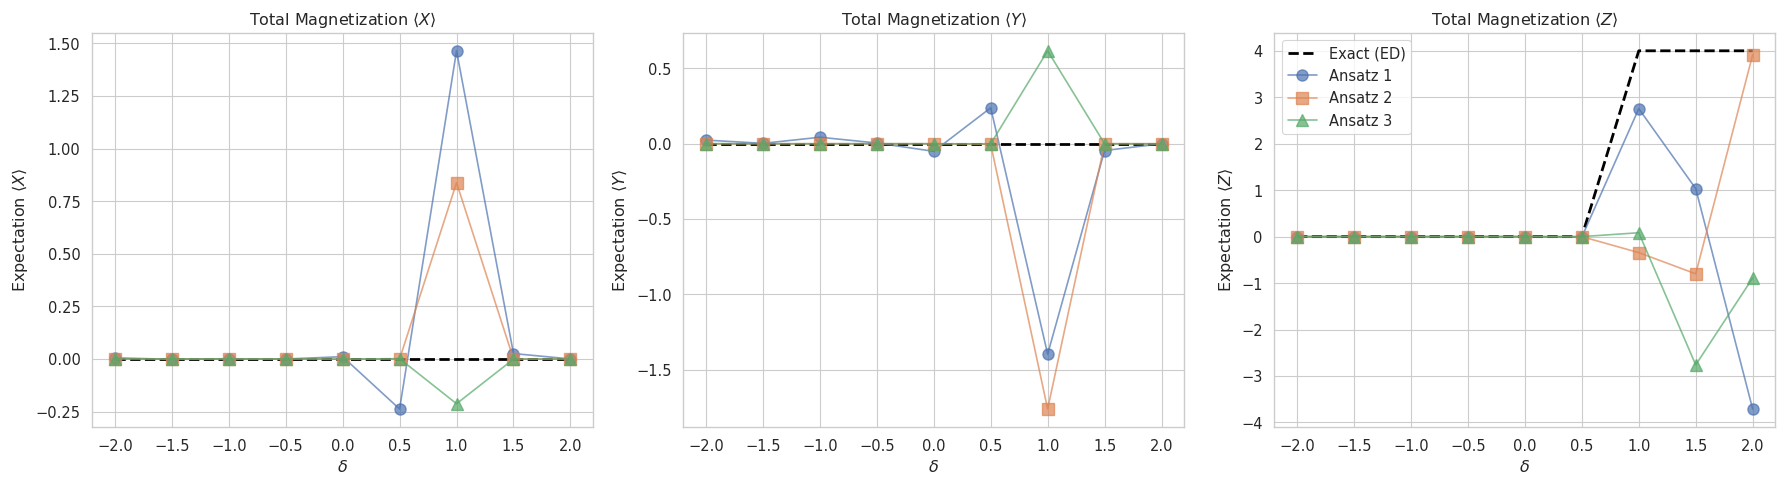

In [ ]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ed_subset = df_expectations_variances_ED[df_expectations_variances_ED["L"] == L]

def plot_observable(ax, obs_name, title):

    col_name = f"exp_{obs_name.lower()}"
    sns.lineplot(data=ed_subset, x="delta", y=col_name, color="black", linestyle="--", linewidth=2, ax=ax, label="Exact (ED)")

    ax.plot(df_expvals_and_vars_1["delta"], df_expvals_and_vars_1[f"exp_{obs_name}"], 'o-', label="Ansatz 1", markersize=8, alpha=0.7)
    ax.plot(df_expvals_and_vars_2["delta"], df_expvals_and_vars_2[f"exp_{obs_name}"], 's-', label="Ansatz 2", markersize=8, alpha=0.7)
    ax.plot(df_expvals_and_vars_3["delta"], df_expvals_and_vars_3[f"exp_{obs_name}"], '^-', label="Ansatz 3", markersize=8, alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel(r"$\delta$")
    ax.set_ylabel(f"Expectation $\\langle {obs_name} \\rangle$")
    if obs_name == "Z":
        ax.legend()
    else:
        ax.get_legend().remove()

# Generate Subplots
plot_observable(axes[0], "X", r"Total Magnetization $\langle X \rangle$")
plot_observable(axes[1], "Y", r"Total Magnetization $\langle Y \rangle$")
plot_observable(axes[2], "Z", r"Total Magnetization $\langle Z \rangle$")

plt.tight_layout()
plt.show()

## **4. Fidelity Comparison**

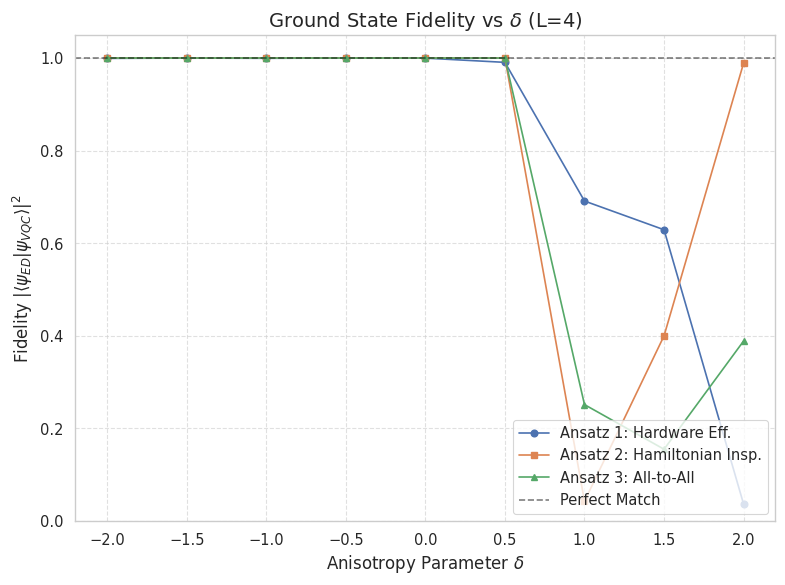

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(df_fidelity_1["delta"], df_fidelity_1["fidelity"], 'o-', label="Ansatz 1: Hardware Eff.")
plt.plot(df_fidelity_2["delta"], df_fidelity_2["fidelity"], 's-', label="Ansatz 2: Hamiltonian Insp.")
plt.plot(df_fidelity_3["delta"], df_fidelity_3["fidelity"], '^-', label="Ansatz 3: All-to-All")

plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, label="Perfect Match")

plt.title(f"Ground State Fidelity vs $\\delta$ (L={L})", fontsize=14)
plt.xlabel(r"Anisotropy Parameter $\delta$", fontsize=12)
plt.ylabel(r"Fidelity $|\langle \psi_{ED} | \psi_{VQC} \rangle|^2$", fontsize=12)
plt.ylim(0.0, 1.05)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## **5. Entanglement Entropy Comparison**

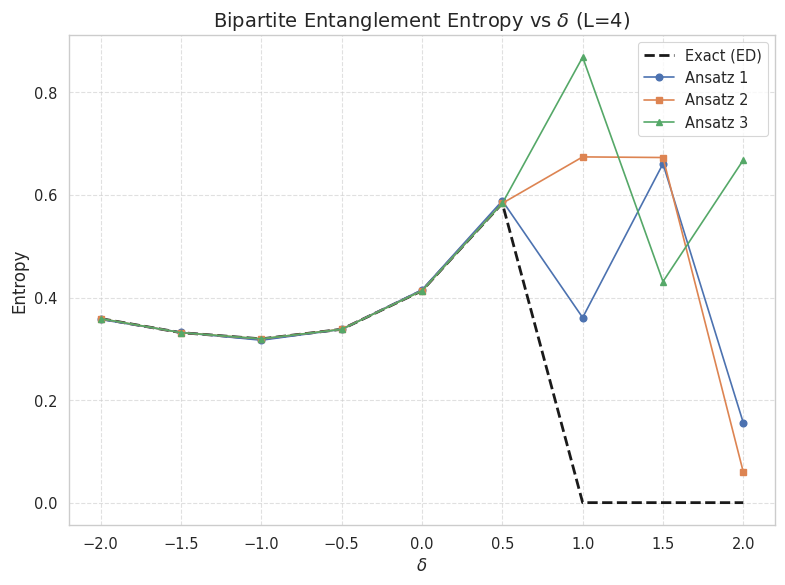

In [ ]:
plt.figure(figsize=(8, 6))

ed_entropy = df_entropies_ED[df_entropies_ED["L"] == L]
plt.plot(ed_entropy["delta"], ed_entropy["Entropy"], 'k--', linewidth=2, label="Exact (ED)")

plt.plot(df_entropy_1["delta"], df_entropy_1["entropy"], 'o-', label="Ansatz 1")
plt.plot(df_entropy_2["delta"], df_entropy_2["entropy"], 's-', label="Ansatz 2")
plt.plot(df_entropy_3["delta"], df_entropy_3["entropy"], '^-', label="Ansatz 3")

plt.title(f"Bipartite Entanglement Entropy vs $\\delta$ (L={L})", fontsize=14)
plt.xlabel(r"$\delta$", fontsize=12)
plt.ylabel(r"Entropy", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## **6. Time Evolution**

Instead of minimizing energy to find the ground state, we are now trying to make our VQC "track" a quantum state as it changes over time.

The system starts in the "all-plus" state $|{+}\rangle^{\otimes L}$, which is an unentangled superposition and evolves under the Hamiltonian as
$|\psi(t)\rangle=e^{-it\hat{H}} |+\rangle^{\otimes L}$.


Our Goal: At specific time snapshots $t_i$, we want to find circuit parameters $\theta_i$ such that our circuit state $|\psi(\theta_i)\rangle$ looks exactly like the real physical state $|\psi(t_i)\rangle$.

To do so, we first need to calculate the Exact target.


In [ ]:
def get_target_states_evolution(L, delta, t_max=4*np.pi, steps=10):
    """
    Pre-calculates the exact quantum states |psi(t)> for all time steps.
    Using eigen-decomposition is O(1) for time-stepping, vs O(N^3) for expm().
    """

    # Initial State |+>|+>...|+>
    plus = np.array([1.0, 1.0], dtype=np.complex128) / np.sqrt(2)
    psi_0 = plus
    for _ in range(L - 1):
        psi_0 = np.kron(psi_0, plus)

    # Diagonalize Hamiltonian using function from Task 1
    H = xxz_hamiltonian(L, delta)
    energies, eigenvectors = eigh(H)

    # coefficients c_n = <eigenvector_n | psi_0>
    coeffs_0 = np.dot(eigenvectors.conj().T, psi_0)

    # States at each time t
    t_values = np.linspace(0, t_max, steps)
    target_states = []

    print(f"Generating exact states for L={L}, delta={delta}...")

    for t in t_values:
        # Time evolution in eigenbasis: c_n(t) = c_n(0) * exp(-i * E_n * t)
        propagator = np.exp(-1j * energies * t)
        coeffs_t = coeffs_0 * propagator

        # Back to computational basis: |psi(t)> = V * c(t)
        psi_t_numpy = np.dot(eigenvectors, coeffs_t)

        psi_t_tensor = pt.tensor(psi_t_numpy, dtype=pt.complex128)
        target_states.append(psi_t_tensor)

    return t_values, target_states

Now we need a loss function to make the optimization loop. We want to maximise the Fidelity, and since PyTorch optimizers minimize loss, we define the following function.

In [ ]:
def get_fidelity_loss(theta, circuit_func, L, p, target_state_tensor):
    """
    Computes the loss for time evolution optimization.

    Args:
        theta: Circuit parameters (requires_grad=True)
        circuit_func: The ansatz function
        L, p: System size and depth
        target_state_tensor: The exact state |psi(t)> (Pre-calculated constant)

    Returns:
        loss: 1 - Fidelity (to minimize)
        fidelity: The actual fidelity value (for logging)
    """
    # Generate Ansatz State
    psi_vqc = circuit_func(theta, L, p)

    # Compute Fidelity w.r.t Target: |<psi_vqc | psi_target>|^2
    overlap = pt.vdot(psi_vqc, target_state_tensor)
    fidelity = pt.abs(overlap)**2

    # Loss = 1 - F (minimizing loss => maximizing fidelity)
    loss = 1.0 - fidelity

    return loss, fidelity

The assignment asks us to compare two ways of finding these parameters:

1. Independent (Random) Initialization: For every time step $t_i$, we reset the circuit with completely random weights and try to optimize from scratch.
    
2. Sequential (Warm Start) Initialization: For time $t_i$, we start with the optimized weights from the previous time step $t_{i-1}$.

For the first method we do the following.

In [ ]:
L = 4
p = 3
steps_per_opt = 50
new_delta_values = [-2, -0.5, 0.5, 2]

def get_num_params(ansatz_name, L, p):
    if ansatz_name == "ansatz_1": return 2 * L * p
    elif ansatz_name == "ansatz_2": return (2 * L + 3 * (L - 1)) * p
    elif ansatz_name == "ansatz_3":
        num_pairs = L * (L - 1) // 2
        return (2 * L + 3 * num_pairs) * p
    return 0

# Storage for results
results_TE = {
    "ansatz_1": [],
    "ansatz_2": [],
    "ansatz_3": []
}

ansatz_list = [
    (ansatz_1, "ansatz_1"),
    (ansatz_2, "ansatz_2"),
    (ansatz_3, "ansatz_3")
]

print(f"Starting Time Evolution Optimization (L={L}, Depth={p})...")

for delta in tqdm(new_delta_values, desc="Delta Loop"):

    # Pre-calculate exact states for this delta
    t_values, target_states = get_target_states_evolution(L, delta, t_max=4*np.pi, steps=10)

    # Loop over Time Steps
    for t_idx, t_i in enumerate(t_values):
        target_state = target_states[t_idx]

        # Loop over Ansatzes
        for circuit_func, name in ansatz_list:

            # Initialize Parameters (Random)
            num_params = get_num_params(name, L, p)
            theta = (pt.rand(num_params, dtype=pt.float64) * 2 * np.pi).requires_grad_(True)
            optimizer = pt.optim.Adam([theta], lr=0.01)

            # Optimization Steps
            for step in range(steps_per_opt):
                loss, _ = get_fidelity_loss(theta, circuit_func, L, p, target_state)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Store Final Result
            _, final_fid = get_fidelity_loss(theta, circuit_func, L, p, target_state)

            results_TE[name].append([delta, t_i, final_fid.item()])

print("Optimization Complete!")

TE_fidelities_1 = results_TE["ansatz_1"]
TE_fidelities_2 = results_TE["ansatz_2"]
TE_fidelities_3 = results_TE["ansatz_3"]

Starting Time Evolution Optimization (L=4, Depth=3)...


Delta Loop:   0%|          | 0/4 [00:00<?, ?it/s]

Generating exact states for L=4, delta=-2...


Delta Loop:  25%|██▌       | 1/4 [00:51<02:35, 51.83s/it]

Generating exact states for L=4, delta=-0.5...


...

Generating exact states for L=4, delta=0.5...


Delta Loop:  75%|███████▌  | 3/4 [02:23<00:47, 47.45s/it]

Generating exact states for L=4, delta=2...


Delta Loop: 100%|██████████| 4/4 [03:10<00:00, 47.59s/it]

Optimization Complete!


And we plot this

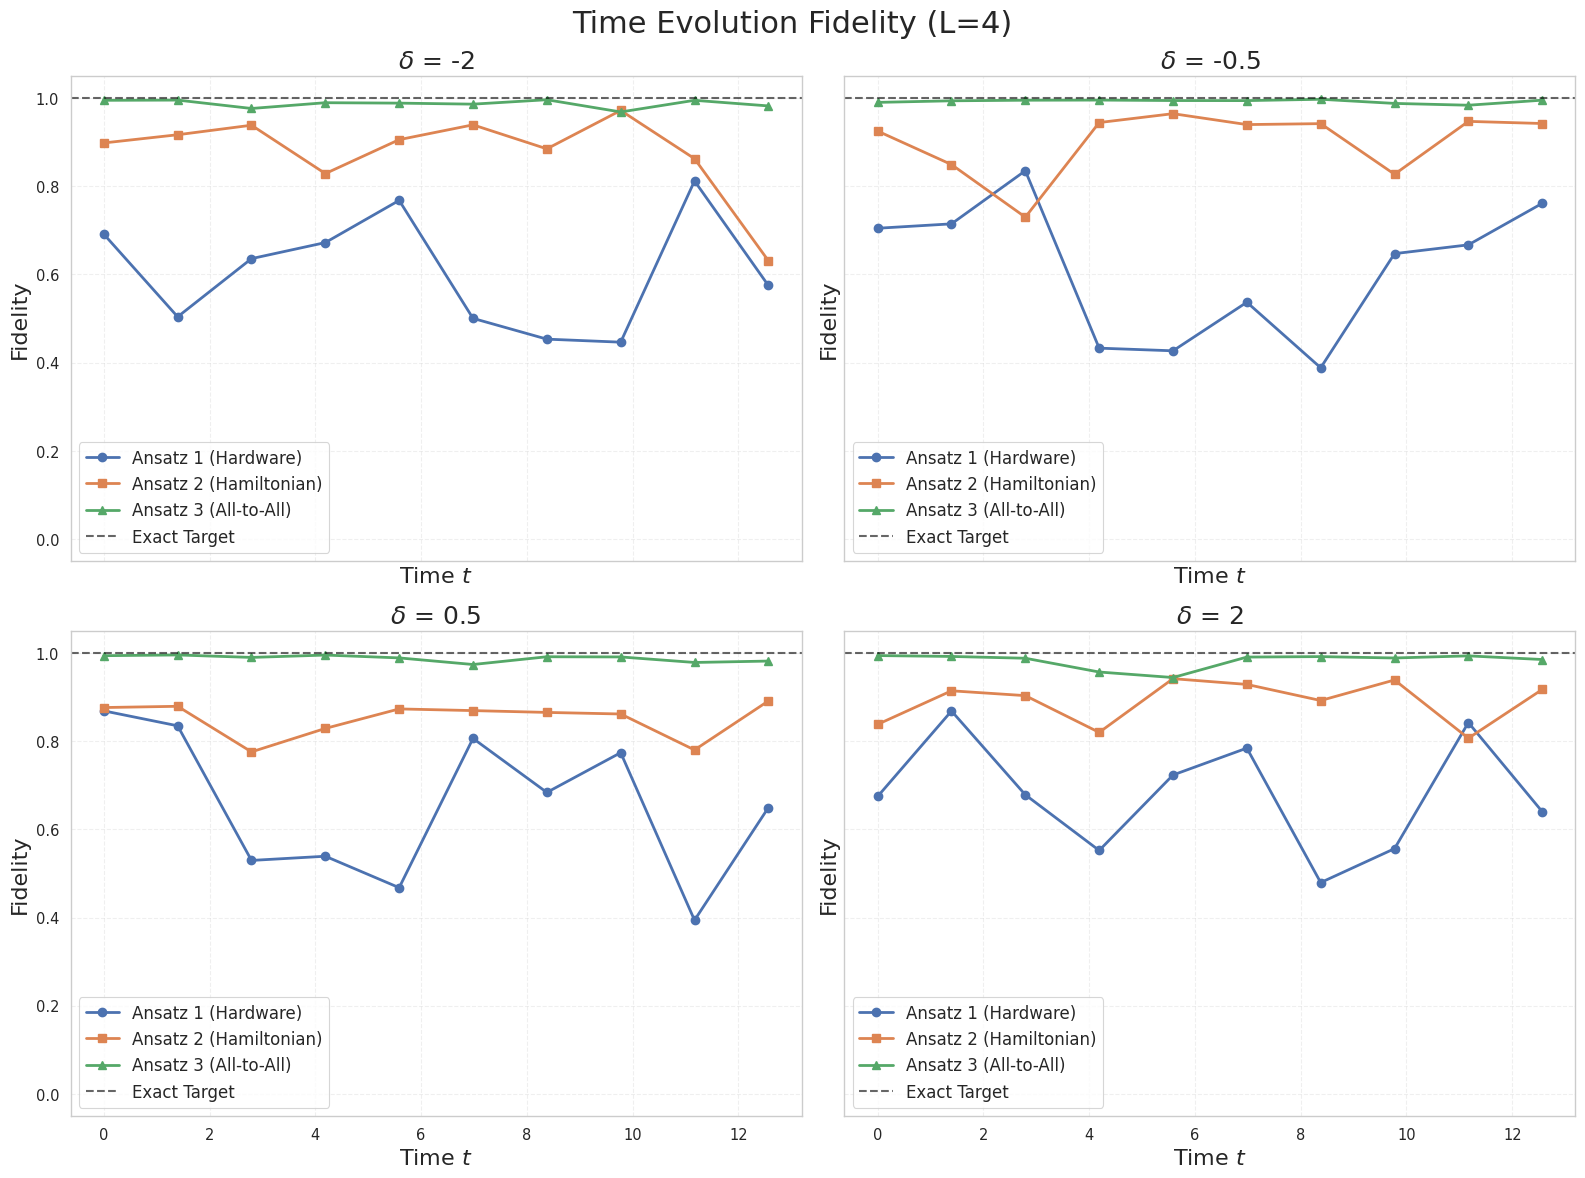

In [ ]:
# Create DataFrames
df_TE_fidelities_1 = pd.DataFrame(TE_fidelities_1, columns=["delta", "t_i", "fidelity"])
df_TE_fidelities_2 = pd.DataFrame(TE_fidelities_2, columns=["delta", "t_i", "fidelity"])
df_TE_fidelities_3 = pd.DataFrame(TE_fidelities_3, columns=["delta", "t_i", "fidelity"])

fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axs = axs.flatten()

for i, delta in enumerate(new_delta_values):
    ax = axs[i]

    df1 = df_TE_fidelities_1[np.isclose(df_TE_fidelities_1["delta"], delta)]
    df2 = df_TE_fidelities_2[np.isclose(df_TE_fidelities_2["delta"], delta)]
    df3 = df_TE_fidelities_3[np.isclose(df_TE_fidelities_3["delta"], delta)]

    ax.plot(df1["t_i"], df1["fidelity"], 'o-', label='Ansatz 1 (Hardware)', markersize=6, linewidth=2)
    ax.plot(df2["t_i"], df2["fidelity"], 's-', label='Ansatz 2 (Hamiltonian)', markersize=6, linewidth=2)
    ax.plot(df3["t_i"], df3["fidelity"], '^-', label='Ansatz 3 (All-to-All)', markersize=6, linewidth=2)

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.6, label="Exact Target")

    ax.set_title(f"$\\delta$ = {delta}", fontsize=18)
    ax.set_xlabel("Time $t$", fontsize=16)
    ax.set_ylabel("Fidelity", fontsize=16)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.3)

    ax.legend(fontsize=12, loc='lower left')

fig.suptitle(f"Time Evolution Fidelity (L={L})", fontsize=22)
fig.tight_layout()
plt.show()

For the second method we act anagously

In [ ]:
steps_warm_start = 50
learning_rate_seq = 0.01

results_TE_sequential = {
    "ansatz_1": [],
    "ansatz_2": [],
    "ansatz_3": []
}

print(f"Starting Sequential (Warm Start) Optimization (L={L})...")

for delta in tqdm(new_delta_values, desc="Delta Loop"):

    # Pre-calculate exact states
    t_values, target_states = get_target_states_evolution(L, delta, t_max=4*np.pi, steps=10)

    # Loop over Ansatzes
    for circuit_func, name in ansatz_list:

        # Initialize Theta ONCE (Random start for t=0)
        num_params = get_num_params(name, L, p)
        theta = (pt.rand(num_params, dtype=pt.float64) * 2 * np.pi).requires_grad_(True)

        # Loop over Time Steps (Warm Start)
        for t_idx, t_i in enumerate(t_values):
            target_state = target_states[t_idx]

            optimizer = pt.optim.Adam([theta], lr=learning_rate_seq)

            # Optimization Steps
            for step in range(steps_warm_start):
                loss, _ = get_fidelity_loss(theta, circuit_func, L, p, target_state)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Store Result
            _, final_fid = get_fidelity_loss(theta, circuit_func, L, p, target_state)

            # The 'theta' variable now holds the optimized values for t_i.
            # In the next iteration of this loop (t_{i+1}), we use this same 'theta' to start
            results_TE_sequential[name].append([delta, t_i, final_fid.item()])

print("Sequential Optimization Complete!")

Starting Sequential (Warm Start) Optimization (L=4)...


Delta Loop:   0%|          | 0/4 [00:00<?, ?it/s]

Generating exact states for L=4, delta=-2...


Delta Loop:  25%|██▌       | 1/4 [00:49<02:27, 49.09s/it]

Generating exact states for L=4, delta=-0.5...


...

Generating exact states for L=4, delta=0.5...


Delta Loop:  75%|███████▌  | 3/4 [02:24<00:47, 47.98s/it]

Generating exact states for L=4, delta=2...


Delta Loop: 100%|██████████| 4/4 [03:11<00:00, 47.86s/it]

Sequential Optimization Complete!


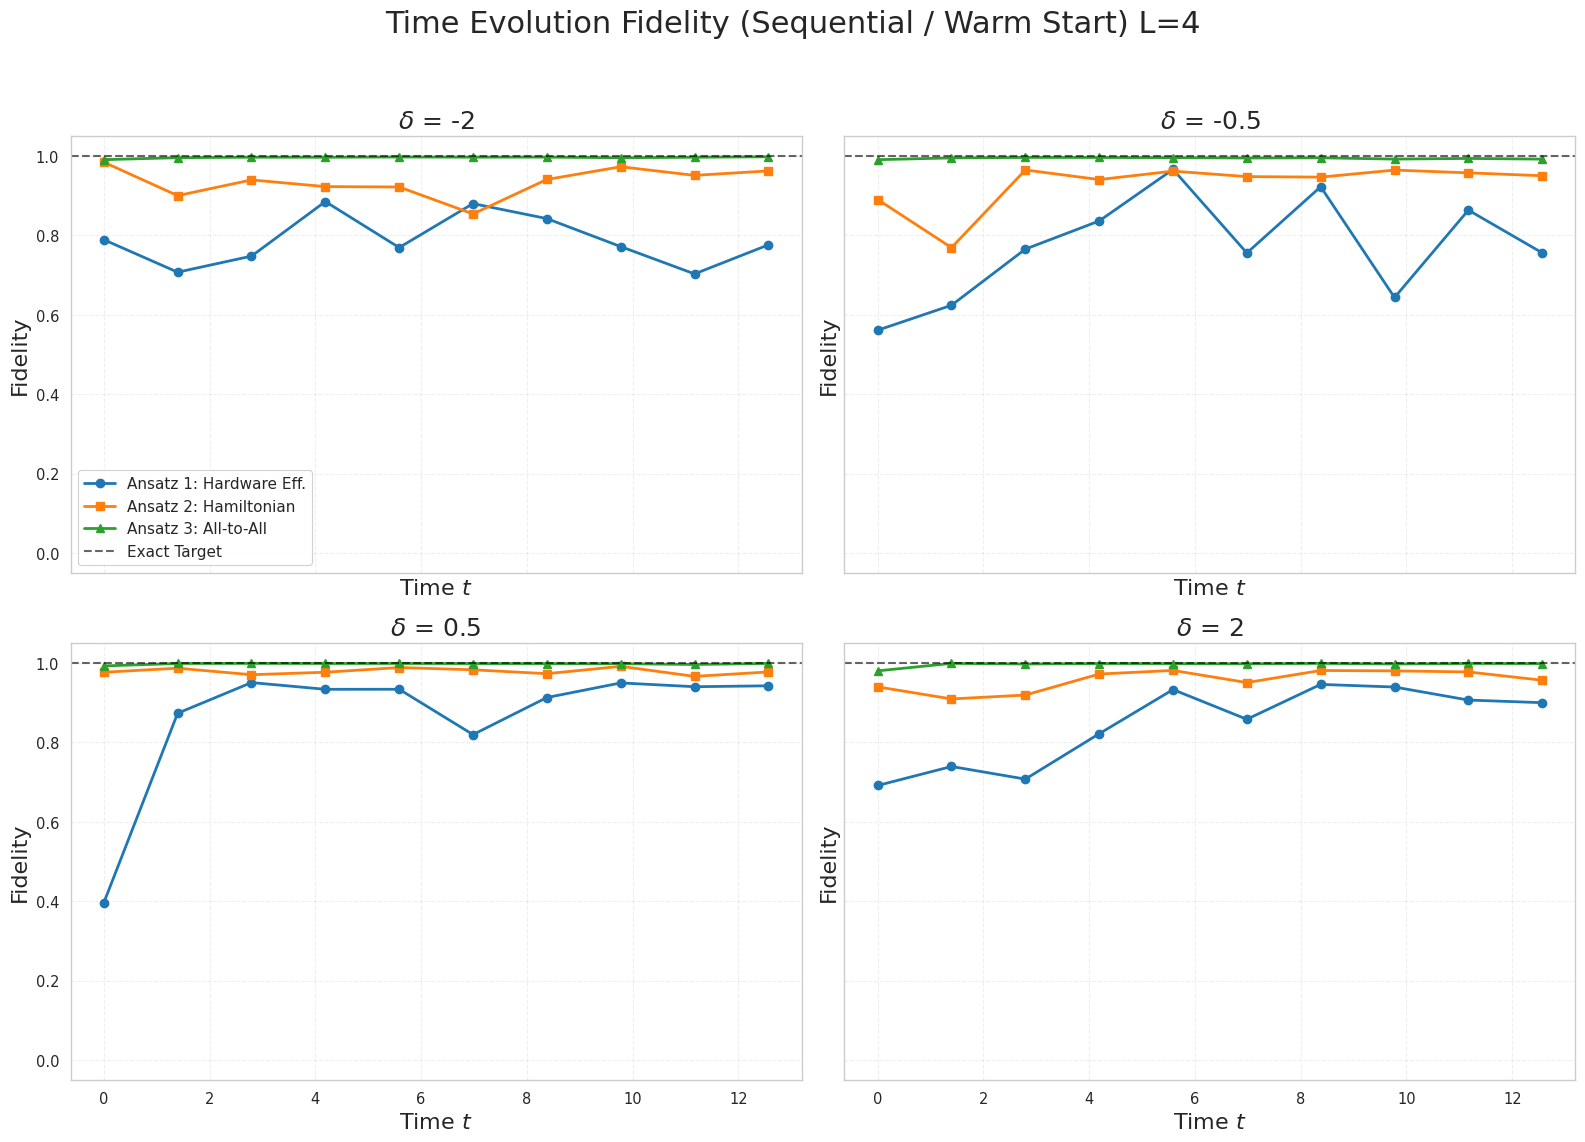

In [ ]:
# Create DataFrames
df_seq_1 = pd.DataFrame(results_TE_sequential["ansatz_1"], columns=["delta", "t_i", "fidelity"])
df_seq_2 = pd.DataFrame(results_TE_sequential["ansatz_2"], columns=["delta", "t_i", "fidelity"])
df_seq_3 = pd.DataFrame(results_TE_sequential["ansatz_3"], columns=["delta", "t_i", "fidelity"])

fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axs = axs.flatten()

for i, delta in enumerate(new_delta_values):
    ax = axs[i]

    df1 = df_seq_1[np.isclose(df_seq_1["delta"], delta)]
    df2 = df_seq_2[np.isclose(df_seq_2["delta"], delta)]
    df3 = df_seq_3[np.isclose(df_seq_3["delta"], delta)]

    ax.plot(df1["t_i"], df1["fidelity"], 'o-',
            label='Ansatz 1: Hardware Eff.', color='tab:blue', markersize=6, linewidth=2)

    ax.plot(df2["t_i"], df2["fidelity"], 's-',
            label='Ansatz 2: Hamiltonian', color='tab:orange', markersize=6, linewidth=2)

    ax.plot(df3["t_i"], df3["fidelity"], '^-',
            label='Ansatz 3: All-to-All', color='tab:green', markersize=6, linewidth=2)

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.6, label="Exact Target")

    ax.set_title(f"$\\delta$ = {delta}", fontsize=18)
    ax.set_xlabel("Time $t$", fontsize=16)
    ax.set_ylabel("Fidelity", fontsize=16)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.3)

    if i == 0:
        ax.legend(fontsize=11, loc='lower left', framealpha=0.9)

fig.suptitle(f"Time Evolution Fidelity (Sequential / Warm Start) L={L}", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Second method better.

Also, worth mentioning that Ansantz 2 and 3 give better results due to their resemblance to the Hamiltonian (XX,YY,ZZ)!!!

## **7. Extra! First Excited State**

To find the first excited state $|\psi_1\rangle$, we will use the same principle as finding the ground state but we add a constraint to the loss function: Be as low energy as possible BUT represent a state that must be orthogonal to the ground state.

Therefore, the new loss function is: $\mathcal{L}(\theta)=\langle \psi(\theta)|H|\psi(\theta)\rangle+\beta|\langle \psi(\theta)|\psi_{GS}\rangle|^2$.

This is because the standard Hamiltonian has the Ground State as its global minimum. To "mask" the Ground State so the optimizer can't see it, we effectively modify the energy landscape. The first term pushes the state down to low energy while the second one acts as a penalty: if the state looks like a ground state, this term shoots up, $\beta$ is a large number (penalty weight).

As a result, the new lowest energy state available to the optimizer becomes the First Excited State.

Thus, we define the following loss function.

In [ ]:
def get_excited_state_loss(theta, circuit_func, L, p, delta, psi_gs_tensor, beta=20.0):
    """
    Computes Loss = Energy + Beta * |<psi|GS>|^2
    """
    # Generate Circuit State
    psi_vqc = circuit_func(theta, L, p)

    # Calculate Energy <psi|H|psi>
    H_numpy = xxz_hamiltonian(L, delta)
    H_tensor = pt.tensor(H_numpy, dtype=pt.complex128)
    energy = pt.vdot(psi_vqc, H_tensor @ psi_vqc).real

    # Calculate Overlap with Ground State (The Penalty)
    overlap = pt.vdot(psi_vqc, psi_gs_tensor)
    overlap_prob = pt.abs(overlap)**2

    # Total Loss
    loss = energy + (beta * overlap_prob)

    return loss, energy, overlap_prob

And use it in the following optimization loop.

In [ ]:
L = 4
p = 3
delta_values = np.linspace(-2, 2, 9)
beta_penalty = 100.0

results_excited = {
    "ansatz_1": {"E": [], "F": [], "Obs": []},
    "ansatz_2": {"E": [], "F": [], "Obs": []},
    "ansatz_3": {"E": [], "F": [], "Obs": []}
}

ansatz_list = [
    (ansatz_1, "ansatz_1"),
    (ansatz_2, "ansatz_2"),
    (ansatz_3, "ansatz_3")
]

print(f"--- Starting Excited State Analysis (L={L}) ---")

for delta in tqdm(delta_values, desc="VQD Scan"):

    # Exact Diagonalization (Reference)
    H_ed = xxz_hamiltonian(L, delta)
    evals, evecs = np.linalg.eigh(H_ed)

    # Identify Ground State (to avoid) and First Excited State (to target)
    psi_0_exact = evecs[:, 0]
    psi_1_exact = evecs[:, 1] # The real target

    psi_0_tensor = pt.tensor(psi_0_exact, dtype=pt.complex128)

    # Optimization Loop
    for circuit_func, name in ansatz_list:

        # Initialize
        num_params = get_num_params(name, L, p)
        theta = (pt.rand(num_params, dtype=pt.float64) * 2 * np.pi).requires_grad_(True)
        optimizer = pt.optim.Adam([theta], lr=0.05)

        # Optimize (Minimize Energy + Penalty)
        for i in range(150):
            loss, _, _ = get_excited_state_loss(theta, circuit_func, L, p, delta, psi_0_tensor, beta=beta_penalty)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Final Evaluation
        final_state = circuit_func(theta, L, p)

        # Energy
        final_E = pt.vdot(final_state, pt.tensor(H_ed, dtype=pt.complex128) @ final_state).real.item()
        results_excited[name]["E"].append([delta, final_E])

        # Fidelity (with Excited State)
        fid = compute_fidelity(psi_1_exact, final_state)
        results_excited[name]["F"].append([delta, fid])

        # X, Y, Z Expectation Values and Variance
        obs = get_exp_val_and_var_pt(L, final_state)
        results_excited[name]["Obs"].append([delta, *obs])

print("Optimization Complete!")

--- Starting Excited State Analysis (L=4) ---


VQD Scan: 100%|██████████| 9/9 [02:11<00:00, 14.66s/it]

Optimization Complete!


To analyse the results we make the following plots:
1. Energy comparison: VQC Energy vs Exact $E_1$
2. Fidelity: Fidelity with Exact $E_1$
3. Observables: VQCs vs Exact $E_1$

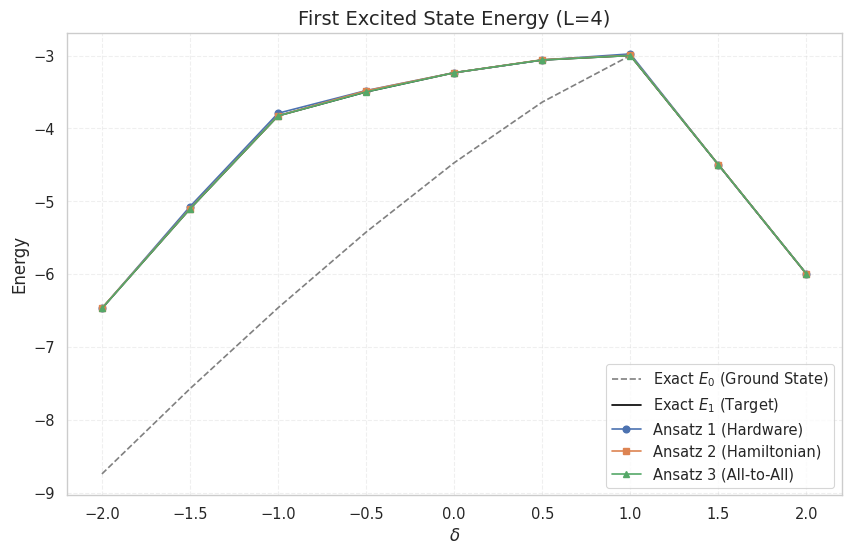

In [ ]:
delta_theory = np.linspace(-2, 2, 9)
theory_E0 = []
theory_E1 = []

for d in delta_theory:
    H_temp = xxz_hamiltonian(L, d)
    evals = np.linalg.eigvalsh(H_temp)
    theory_E0.append(evals[0]) # Ground State
    theory_E1.append(evals[1]) # First Excited State

# 2. Create DataFrames
df_res_E_1 = pd.DataFrame(results_excited["ansatz_1"]["E"], columns=["delta", "energy"])
df_res_E_2 = pd.DataFrame(results_excited["ansatz_2"]["E"], columns=["delta", "energy"])
df_res_E_3 = pd.DataFrame(results_excited["ansatz_3"]["E"], columns=["delta", "energy"])

plt.figure(figsize=(10, 6))

plt.plot(delta_theory, theory_E0, color='gray', linestyle='--', alpha=1, label=r"Exact $E_0$ (Ground State)")
plt.plot(delta_theory, theory_E1, color='black', linestyle='-',  alpha=1, label=r"Exact $E_1$ (Target)")

plt.plot(df_res_E_1["delta"], df_res_E_1["energy"], 'o-', label="Ansatz 1 (Hardware)")
plt.plot(df_res_E_2["delta"], df_res_E_2["energy"], 's-', label="Ansatz 2 (Hamiltonian)")
plt.plot(df_res_E_3["delta"], df_res_E_3["energy"], '^-', label="Ansatz 3 (All-to-All)")

plt.title(f"First Excited State Energy (L={L})", fontsize=14)
plt.xlabel(r"$\delta$", fontsize=12)
plt.ylabel("Energy", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


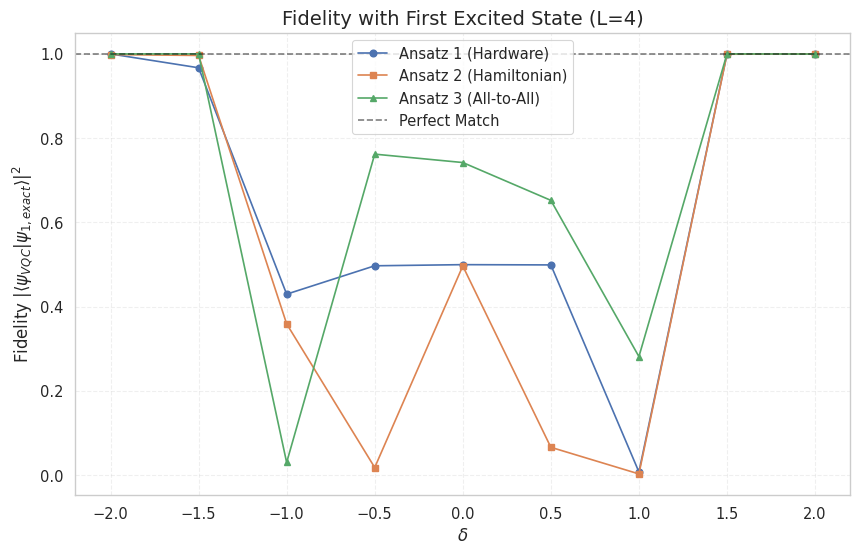

In [ ]:
# Create DataFrames
df_res_es_1 = pd.DataFrame(results_excited["ansatz_1"]["F"], columns=["delta", "fidelity"])
df_res_es_2 = pd.DataFrame(results_excited["ansatz_2"]["F"], columns=["delta", "fidelity"])
df_res_es_3 = pd.DataFrame(results_excited["ansatz_3"]["F"], columns=["delta", "fidelity"])

plt.figure(figsize=(10, 6))

plt.plot(df_res_es_1["delta"], df_res_es_1["fidelity"], 'o-', label="Ansatz 1 (Hardware)")
plt.plot(df_res_es_2["delta"], df_res_es_2["fidelity"], 's-', label="Ansatz 2 (Hamiltonian)")
plt.plot(df_res_es_3["delta"], df_res_es_3["fidelity"], '^-', label="Ansatz 3 (All-to-All)")

plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, label="Perfect Match")

plt.title(f"Fidelity with First Excited State (L={L})", fontsize=14)
plt.xlabel(r"$\delta$", fontsize=12)
plt.ylabel(r"Fidelity $|\langle \psi_{VQC} | \psi_{1, exact} \rangle|^2$", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

The drop in fidelity at $\delta=1.0$ is expected and highlights a specific challenge in quantum simulation.

And it is due to the fact that it represents a Critical Phase Transition. The point $\delta=1.0$ is the isotropic Heisenberg limit. This is a Critical Point separating the XY phase ($\delta< 1.0$) from the Ferromagnetic Ising phase ($\delta> 1.0$).

In [ ]:
# Create DataFrame
exact_excited_data = []

for delta in delta_values:
    H_ed = xxz_hamiltonian(L, delta)
    _, evecs = np.linalg.eigh(H_ed)

    psi_1 = evecs[:, 1]

    # Expectation values
    obs_vals = []
    for op_matrix in [sigma_x, sigma_y, sigma_z]:
        total_op = total_sigma_operator(L, op_matrix)
        exp_val = np.vdot(psi_1, total_op @ psi_1).real

        # Variances
        exp_sq = np.vdot(psi_1, total_op @ (total_op @ psi_1)).real
        var = exp_sq - exp_val**2

        obs_vals.extend([exp_val, var])

    exact_excited_data.append([delta, *obs_vals])

cols_obs = ["delta", "exp_X", "var_X", "exp_Y", "var_Y", "exp_Z", "var_Z"]
df_exact_excited = pd.DataFrame(exact_excited_data, columns=cols_obs)

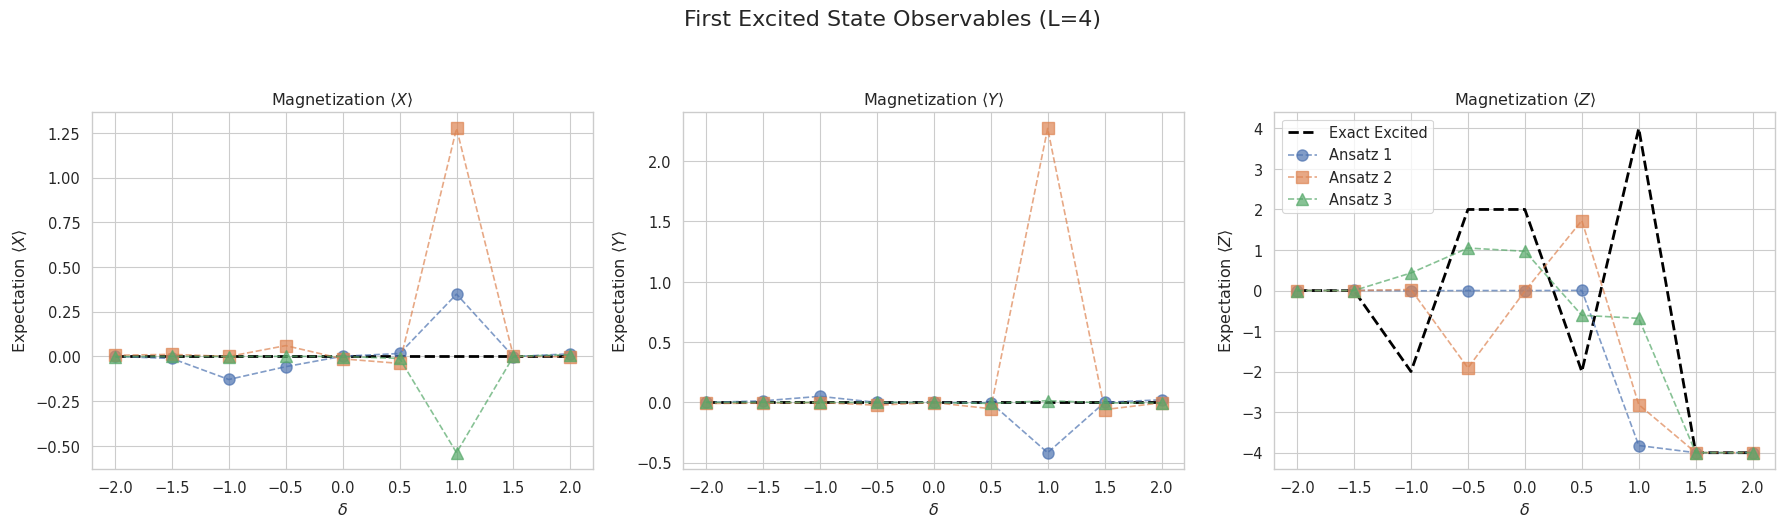

In [ ]:
# Create DataFrames
cols_obs_vqc = ["delta", "exp_X", "var_X", "exp_Y", "var_Y", "exp_Z", "var_Z"]

df_obs_1 = pd.DataFrame(results_excited["ansatz_1"]["Obs"], columns=cols_obs_vqc)
df_obs_2 = pd.DataFrame(results_excited["ansatz_2"]["Obs"], columns=cols_obs_vqc)
df_obs_3 = pd.DataFrame(results_excited["ansatz_3"]["Obs"], columns=cols_obs_vqc)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_observable_comparison(ax, obs_char, title):
    col_exp = f"exp_{obs_char}"

    sns.lineplot(data=df_exact_excited, x="delta", y=col_exp,
                 color="black", linestyle="--", linewidth=2, ax=ax, label="Exact Excited")

    ax.plot(df_obs_1["delta"], df_obs_1[col_exp], 'o--', label="Ansatz 1", markersize=8, alpha=0.7)
    ax.plot(df_obs_2["delta"], df_obs_2[col_exp], 's--', label="Ansatz 2", markersize=8, alpha=0.7)
    ax.plot(df_obs_3["delta"], df_obs_3[col_exp], '^--', label="Ansatz 3", markersize=8, alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel(r"$\delta$")
    ax.set_ylabel(f"Expectation $\\langle {obs_char} \\rangle$")

    if obs_char == "Z":
        ax.legend()
    else:
        if ax.get_legend(): ax.get_legend().remove()

plot_observable_comparison(axes[0], "X", r"Magnetization $\langle X \rangle$")
plot_observable_comparison(axes[1], "Y", r"Magnetization $\langle Y \rangle$")
plot_observable_comparison(axes[2], "Z", r"Magnetization $\langle Z \rangle$")

plt.suptitle(f"First Excited State Observables (L={L})", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

## **8. Additional Analysis**

### 8.1. The "Odd vs. Even" Effect (Kramers Degeneracy)

*Hypothesis:*  The spectrum of the XXZ chain depends fundamentally on whether the number of spins $L$ is even or odd.

*Our Analysis:*

- For $L=4$ (Even): The ground state is a unique singlet ($S=0$) in the antiferromagnetic phase ($\delta>1$). There is a clear gap to the excited state.

- For $L=5$ (Odd): The total spin is half-integer ($1/2$). Due to Time-Reversal Symmetry, Kramers' theorem mandates that every energy level is doubly degenerate ($E_0=E_1$).

Reusing part of Task 7:

In [ ]:
L = 5
p = 3
delta_values = np.linspace(-2, 2, 9)
beta_penalty = 100.0

results_excited = {
    "ansatz_1": {"E": [], "F": [], "Obs": []},
    "ansatz_2": {"E": [], "F": [], "Obs": []},
    "ansatz_3": {"E": [], "F": [], "Obs": []}
}

ansatz_list = [
    (ansatz_1, "ansatz_1"),
    (ansatz_2, "ansatz_2"),
    (ansatz_3, "ansatz_3")
]

print(f"--- Starting Excited State Analysis (L={L}) ---")

for delta in tqdm(delta_values, desc="VQD Scan"):

    # Exact Diagonalization (Reference)
    H_ed = xxz_hamiltonian(L, delta)
    evals, evecs = np.linalg.eigh(H_ed)

    # Identify Ground State (to avoid) and First Excited State (to target)
    psi_0_exact = evecs[:, 0]
    psi_1_exact = evecs[:, 1]

    psi_0_tensor = pt.tensor(psi_0_exact, dtype=pt.complex128)

    # Optimization Loop
    for circuit_func, name in ansatz_list:

        # Initialize
        num_params = get_num_params(name, L, p)
        theta = (pt.rand(num_params, dtype=pt.float64) * 2 * np.pi).requires_grad_(True)
        optimizer = pt.optim.Adam([theta], lr=0.05)

        # Optimize (Minimize Energy + Penalty)
        for i in range(150):
            loss, _, _ = get_excited_state_loss(theta, circuit_func, L, p, delta, psi_0_tensor, beta=beta_penalty)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Final Evaluation
        final_state = circuit_func(theta, L, p)

        # Energy
        final_E = pt.vdot(final_state, pt.tensor(H_ed, dtype=pt.complex128) @ final_state).real.item()
        results_excited[name]["E"].append([delta, final_E])

        # Fidelity (with Excited State)
        fid = compute_fidelity(psi_1_exact, final_state)
        results_excited[name]["F"].append([delta, fid])

        # X, Y, Z Expectation Values and Variance
        obs = get_exp_val_and_var_pt(L, final_state)
        results_excited[name]["Obs"].append([delta, *obs])

print("Optimization Complete!")

--- Starting Excited State Analysis (L=5) ---


VQD Scan: 100%|██████████| 9/9 [03:20<00:00, 22.25s/it]

Optimization Complete!


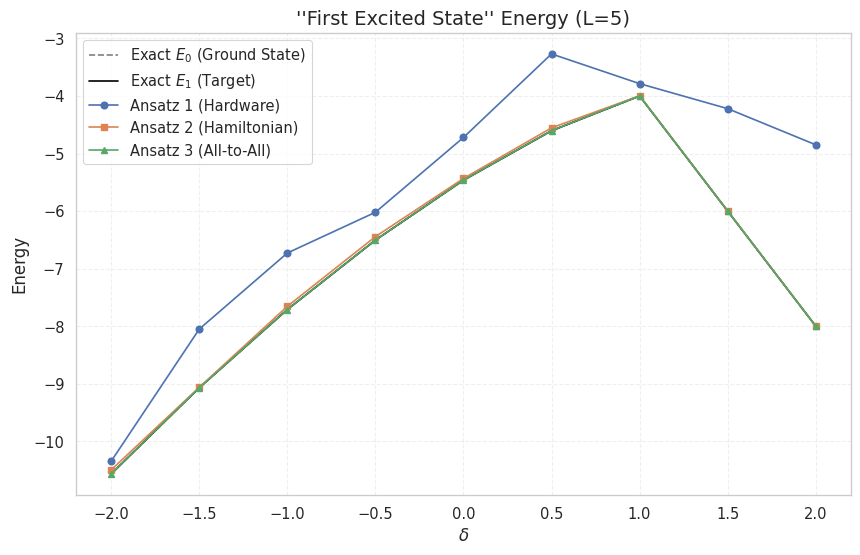

In [ ]:
delta_theory = np.linspace(-2, 2, 9)
theory_E0 = []
theory_E1 = []

for d in delta_theory:
    H_temp = xxz_hamiltonian(L, d)
    evals = np.linalg.eigvalsh(H_temp)
    theory_E0.append(evals[0])
    theory_E1.append(evals[1])

# 2. Create DataFrames
df_res_E_1 = pd.DataFrame(results_excited["ansatz_1"]["E"], columns=["delta", "energy"])
df_res_E_2 = pd.DataFrame(results_excited["ansatz_2"]["E"], columns=["delta", "energy"])
df_res_E_3 = pd.DataFrame(results_excited["ansatz_3"]["E"], columns=["delta", "energy"])

plt.figure(figsize=(10, 6))

plt.plot(delta_theory, theory_E0, color='gray', linestyle='--', alpha=1, label=r"Exact $E_0$ (Ground State)")
plt.plot(delta_theory, theory_E1, color='black', linestyle='-',  alpha=1, label=r"Exact $E_1$ (Target)")

plt.plot(df_res_E_1["delta"], df_res_E_1["energy"], 'o-', label="Ansatz 1 (Hardware)")
plt.plot(df_res_E_2["delta"], df_res_E_2["energy"], 's-', label="Ansatz 2 (Hamiltonian)")
plt.plot(df_res_E_3["delta"], df_res_E_3["energy"], '^-', label="Ansatz 3 (All-to-All)")

plt.title(f"''First Excited State'' Energy (L={L})", fontsize=14)
plt.xlabel(r"$\delta$", fontsize=12)
plt.ylabel("Energy", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Conclusion: Standard VQD algorithms fail for odd L because they just find the degenerate partner of the ground state. We must modify the penalty term to orthogonalize against the entire ground-state subspace.

In [ ]:
def get_ground_subspace_and_target(L, delta, tolerance=1e-5):
    """
    Identifies all degenerate ground states to avoid and finds the
    energy of the first physical excited state.
    """
    # Exact Diagonalization
    H_numpy = xxz_hamiltonian(L, delta)
    evals, evecs = np.linalg.eigh(H_numpy)

    # Identify Ground Energy
    E0 = evals[0]

    # Find all states in the Ground State Subspace (Degenerate)
    deg_indices = [i for i, e in enumerate(evals) if abs(e - E0) < tolerance]

    states_to_avoid = []
    for idx in deg_indices:
        psi_vec = evecs[:, idx]
        states_to_avoid.append(pt.tensor(psi_vec, dtype=pt.complex128))

    # Identify the "Physical" Target Energy (First gap)
    # The first index NOT in the degenerate list
    if len(deg_indices) < len(evals):
        target_idx = deg_indices[-1] + 1
        E_target_physical = evals[target_idx]
        psi_target_physical = evecs[:, target_idx]
    else:
        E_target_physical = E0
        psi_target_physical = evecs[:, 0]

    return states_to_avoid, E_target_physical, psi_target_physical

In [ ]:
def get_generalized_vqd_loss(theta, circuit_func, L, p, delta, states_to_avoid, beta=50.0):
    """
    Loss = Energy + Beta * Sum( Overlap_i )
    """
    psi_vqc = circuit_func(theta, L, p)

    # Energy Term
    H_numpy = xxz_hamiltonian(L, delta)
    H_tensor = pt.tensor(H_numpy, dtype=pt.complex128)
    energy = pt.vdot(psi_vqc, H_tensor @ psi_vqc).real

    # Subspace Penalty Term
    penalty_sum = 0.0
    for psi_avoid in states_to_avoid:
        # Calculate overlap with each ground state vector
        overlap = pt.vdot(psi_vqc, psi_avoid)
        penalty_sum += beta * (pt.abs(overlap)**2)

    return energy + penalty_sum, energy

In [ ]:
# We can now change L to 4, 5, 6... it handles it automatically!
L_universal = 5
delta_values = np.linspace(-2, 2, 9)
p = 3

results_universal = {
    "ansatz_3": {"delta": [], "E_vqc": [], "E_exact_target": [], "F_physical": []}
}

print(f"--- Running Universal VQD for L={L_universal} ---")

for delta in tqdm(delta_values, desc="Universal Scan"):

    states_to_avoid, E_target_ref, psi_target_ref = get_ground_subspace_and_target(L_universal, delta)

    # Optimization
    # Initialize
    num_params = get_num_params("ansatz_3", L_universal, p)
    theta = (pt.rand(num_params, dtype=pt.float64) * 2 * np.pi).requires_grad_(True)
    optimizer = pt.optim.Adam([theta], lr=0.05)

    # Loop
    for i in range(150):
        loss, _ = get_generalized_vqd_loss(theta, ansatz_3, L_universal, p, delta, states_to_avoid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Final Evaluation
    final_state = ansatz_3(theta, L_universal, p)
    final_H = xxz_hamiltonian(L_universal, delta)
    final_E = pt.vdot(final_state, pt.tensor(final_H, dtype=pt.complex128) @ final_state).real.item()

    fid = compute_fidelity(psi_target_ref, final_state)

    results_universal["ansatz_3"]["delta"].append(delta)
    results_universal["ansatz_3"]["E_vqc"].append(final_E)
    results_universal["ansatz_3"]["E_exact_target"].append(E_target_ref)
    results_universal["ansatz_3"]["F_physical"].append(fid)

print("Done!")

--- Running Universal VQD for L=5 ---


Universal Scan: 100%|██████████| 9/9 [01:53<00:00, 12.65s/it]

Done!


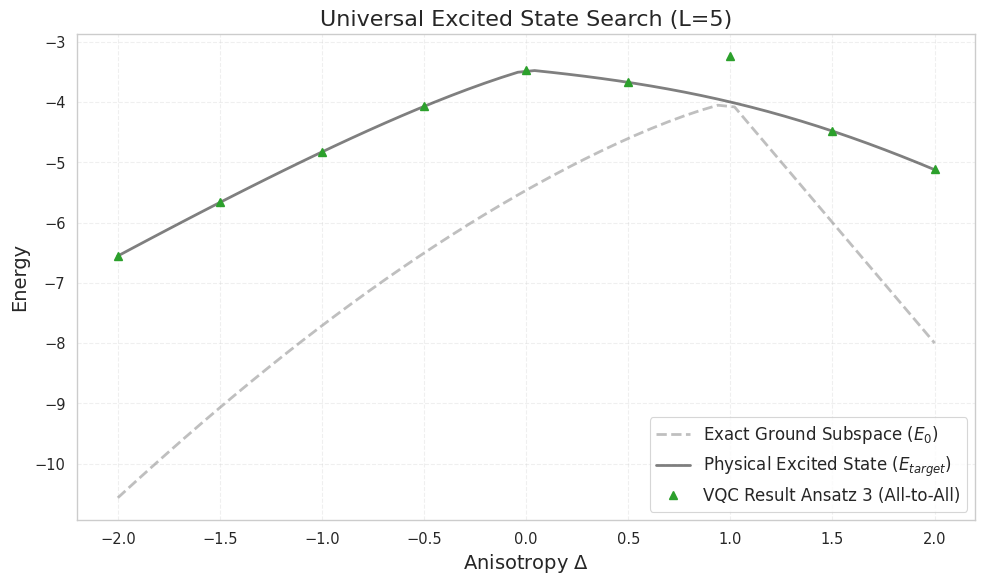

In [ ]:
def plot_universal_vqd_results(results_dict, L_sys, ansatz_name="ansatz_3"):
    """
    Plots VQC results against the exact physical spectrum for any L.
    """

    delta_theory = np.linspace(-2, 2, 50)
    theory_E0 = []
    theory_Target = []

    for d in delta_theory:
        H_temp = xxz_hamiltonian(L_sys, d)
        evals = np.linalg.eigvalsh(H_temp)

        e0 = evals[0]
        theory_E0.append(e0)

        physical_excited = evals[evals > (e0 + 1e-5)]

        if len(physical_excited) > 0:
            theory_Target.append(physical_excited[0])
        else:
            theory_Target.append(e0)

    data = results_dict[ansatz_name]
    df = pd.DataFrame(data)

    plt.figure(figsize=(10, 6))

    plt.plot(delta_theory, theory_E0, color='gray', linestyle='--', linewidth=2, alpha=0.5,
             label=f"Exact Ground Subspace ($E_0$)")

    plt.plot(delta_theory, theory_Target, color='black', linestyle='-', linewidth=2, alpha=0.5,
             label=f"Physical Excited State ($E_{{target}}$)")

    plt.plot(df["delta"], df["E_vqc"], '^', color='tab:green', markersize=6, label="VQC Result Ansatz 3 (All-to-All)")

    plt.title(f"Universal Excited State Search (L={L_sys})", fontsize=16)
    plt.xlabel(r"Anisotropy $\Delta$", fontsize=14)
    plt.ylabel("Energy", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_universal_vqd_results(results_universal, L_universal, "ansatz_3")